<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-Individual-Project/blob/main/EMSC2010_Individual_Project_U7488277.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview

##Overview

### **Five-Layer Earth Energy Balance Model with Monte Carlo Uncertainty Quantification**

# Project Overview

This project develops, calibrates, and evaluates a physically grounded five-layer Energy Balance Model (EBM) of the Earth's climate system. Rather than adopting parameters from literature, all major model constants are derived empirically from observational datasets using statistical techniques including Bayesian regression, constrained optimisation, and spectral analysis.

The calibrated model is then run as a Monte Carlo ensemble to quantify how uncertainty in physical parameters propagates into uncertainty in future climate projections under two contrasting CO$_2$ emissions scenarios.

---

# 1. Introduction and Motivation

Earth's global mean temperature is governed by the balance between incoming solar radiation and outgoing longwave radiation. Simple Energy Balance Models capture this physics analytically and, despite their simplicity, reproduce many features of observed climate change. This makes them useful tools for understanding the sensitivity of climate to physical parameters and forcing scenarios.

Most published EBMs adopt parameter values from literature or radiative transfer models. This project takes a different approach: every tunable parameter is estimated directly from ERA5 reanalysis data and observational records using formal statistical methods. This allows uncertainty in each parameter to be quantified and propagated through the model, producing probabilistic rather than deterministic forecasts.

The central research questions are:

1. How sensitive is projected warming to uncertainty in physical parameters versus uncertainty in future CO$_2$ emissions?
2. Which parameters contribute most to forecast uncertainty?
3. Under what conditions does the model predict climate tipping points?

---

# 2. Model Structure

## 2.1 Layer Architecture

The model represents five coupled thermal reservoirs governed by a system of ordinary differential equations integrated using the forward Euler method.

| Layer | Physical meaning | Heat capacity source |
|---|---|---|
| $T_s$ | Surface: land + ocean mixed layer, 0–50 m | Derived from material properties |
| $T_{a2}$ | Lower atmosphere: troposphere, 500–1000 hPa | Derived from pressure thickness |
| $T_{a1}$ | Upper atmosphere: upper troposphere, 200–500 hPa | Derived from pressure thickness |
| $T_{d1}$ | Upper deep ocean, 0–2000 m | Derived from seawater density and heat capacity |
| $T_{d2}$ | Lower deep ocean, 2000–6000 m | Derived from seawater density and heat capacity |

---

## 2.2 Governing Equations

### Surface layer

$$
C_s \frac{dT_s}{dt}
=
\frac{(1-\alpha)S}{4}
+
\varepsilon\sigma T_{a2}^4
+
(1-\varepsilon)\varepsilon\sigma T_{a1}^4
-
\sigma T_s^4
+
F_{CO_2}
-
\gamma_1(T_s-T_{d1})
+
F_{\text{volc}}
+
\eta
$$

### Lower atmosphere

$$
C_{a2}\frac{dT_{a2}}{dt}
=
\varepsilon\sigma T_s^4
+
\varepsilon^2\sigma T_{a1}^4
-
2\varepsilon\sigma T_{a2}^4
$$

### Upper atmosphere

$$
C_{a1}\frac{dT_{a1}}{dt}
=
\varepsilon(1-\varepsilon)\sigma T_s^4
+
\varepsilon^2\sigma T_{a2}^4
-
2\varepsilon\sigma T_{a1}^4
$$

### Upper deep ocean

$$
C_{d1}\frac{dT_{d1}}{dt}
=
\gamma_1(T_s-T_{d1})
-
\gamma_2(T_{d1}-T_{d2})
$$

### Lower deep ocean

$$
C_{d2}\frac{dT_{d2}}{dt}
=
\gamma_2(T_{d1}-T_{d2})
$$

---

## 2.3 External Forcings

### Solar insolation

Solar insolation is reconstructed from observed total solar irradiance using Fourier analysis:

$$
S(t)
=
S_0
+
A_{11}\cos\left(\frac{2\pi t}{11}+\phi_{11}\right)
+
A_{22}\cos\left(\frac{2\pi t}{22}+\phi_{22}\right)
$$

### CO$_2$ radiative forcing

CO$_2$ radiative forcing uses the logarithmic Myhre parameterisation:

$$
F_{CO_2}(t)
=
5.35
\ln\left(\frac{C(t)}{C_0}\right)
$$

### Ice-albedo feedback

Ice-albedo feedback is represented using a logistic sigmoid function:

$$
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max}-\alpha_{\min}}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

### Volcanic forcing

Volcanic forcing is represented as a stochastic Poisson process with exponential decay, parameterised from observational records.

---

# 3. Observational Datasets

| Dataset | Source | Variables used |
|---|---|---|
| GISTEMP surface temperature | NASA GISS | $T_s$ calibration, validation, nudging |
| ERA5 TOA net longwave flux | Copernicus / ECMWF | OLR, emissivity derivation |
| ERA5 TOA net/downward shortwave flux | Copernicus / ECMWF | Planetary albedo |
| ERA5 surface shortwave fluxes | Copernicus / ECMWF | Albedo sigmoid fitting |
| Mauna Loa CO$_2$ | NOAA GML | CO$_2$ growth rate and seasonal cycle |
| TSI composite | LASP / SORCE-TIM | $S_0$, $A_{11}$, $A_{22}$, phase extraction |
| Argo 0–2000 m ocean temperature | Scripps / Argo | $\gamma_1$ derivation, $T_{d1}$ initialisation |
| Argo 2000–6000 m ocean temperature | Scripps / Argo | $\gamma_2$ derivation, $T_{d2}$ initialisation |

---

# 4. Parameter Derivation Methods

## 4.1 Atmospheric Emissivity, $\varepsilon$

Atmospheric emissivity is derived from the two-layer outgoing longwave radiation expression:

$$
OLR
=
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

Rearranging gives:

$$
\varepsilon
=
\frac{2(\sigma T_s^4-OLR)}
{\sigma T_s^4+OLR}
$$

This is fitted using Bayesian linear regression with `bambi`/PyMC. The predictor and response are defined as:

$$
x = \sigma T_s^4 + OLR
$$

$$
y = \sigma T_s^4 - OLR
$$

The posterior distribution is used to estimate the mean value and 95% HDI for $\varepsilon$.

---

## 4.2 Ocean Heat Exchange Coefficients, $\gamma_1$ and $\gamma_2$

The lower ocean exchange coefficient $\gamma_2$ is derived from:

$$
C_{d2}\frac{dT_{d2}}{dt}
=
\gamma_2(T_{d1}-T_{d2})
$$

This is estimated by regressing:

$$
C_{d2}\dot{T}_{d2}
$$

against:

$$
T_{d1}-T_{d2}
$$

The upper-ocean exchange coefficient $\gamma_1$ is derived from:

$$
C_{d1}\frac{dT_{d1}}{dt}
+
\gamma_2(T_{d1}-T_{d2})
=
\gamma_1(T_s-T_{d1})
$$

This is estimated by regressing the adjusted heat storage rate against:

$$
T_s-T_{d1}
$$

Both coefficients are fitted using Bayesian regression through the origin.

---

## 4.3 Albedo Parameters

The temperature-dependent albedo function is:

$$
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max}-\alpha_{\min}}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

The parameters $\alpha_{\min}$ and $\alpha_{\max}$ are first estimated from surface-type albedos and ocean/land fractions.

The parameters $T_{\text{ice}}$ and $\Delta T$ are fitted using constrained differential evolution optimisation. The objective function requires:

1. low mean squared error against observed ERA5 albedo,
2. exactly three energy-balance equilibria,
3. the correct stable-unstable-stable equilibrium structure,
4. a warm stable equilibrium near modern global mean temperature.

Bootstrap resampling is used to estimate uncertainty in the albedo parameters.

---

## 4.4 Solar Parameters

The mean solar constant $S_0$ is calculated as the observed mean total solar irradiance.

The amplitudes and phases of the 11-year and 22-year solar cycles are extracted from the FFT amplitude and phase spectrum of detrended TSI observations.

The reconstructed solar forcing is:

$$
S(t)
=
S_0
+
A_{11}\cos\left(\frac{2\pi t}{11}+\phi_{11}\right)
+
A_{22}\cos\left(\frac{2\pi t}{22}+\phi_{22}\right)
$$

---

## 4.5 CO$_2$ Growth Rate and Seasonal Cycle

The long-term CO$_2$ trend is fitted using a sixth-order polynomial applied to the monthly Mauna Loa CO$_2$ record.

The seasonal cycle is extracted from the residuals using FFT at 1 cycle per year.

The reconstructed CO$_2$ pathway is:

$$
C(t)
=
\text{polynomial}(t)
+
A_{\text{ann}}
\cos(2\pi t+\phi_{\text{ann}})
$$

---

## 4.6 Atmospheric Heat Capacities

Atmospheric heat capacity is derived from:

$$
C_a
=
\frac{C_p \Delta p}{g}
$$

where:

- $C_p$ is the specific heat capacity of dry air,
- $\Delta p$ is the pressure thickness of the atmospheric layer,
- $g$ is gravitational acceleration.

---

# 5. Equilibrium Analysis and Spin-Up

Before any future CO$_2$ forcing is applied, the model is integrated under pre-industrial conditions:

$$
C = C_0
$$

with:

$$
S = S_0
$$

and no volcanic forcing or weather noise.

This spin-up is performed independently for each Monte Carlo ensemble member using its sampled parameter set. This ensures the model starts from its own internally consistent pre-industrial equilibrium.

The simplified energy-balance curve is:

$$
F(T_s)
=
\frac{(1-\alpha)S}{4}
-
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

Zero-crossings of this curve represent climate equilibria.

The fitted parameters are expected to support a three-equilibrium climate system:

1. cold stable snowball equilibrium,
2. intermediate unstable tipping point,
3. warm stable present-day equilibrium.

---

# 6. Monte Carlo Uncertainty Quantification

## 6.1 Parameter Sampling

For each ensemble member, parameters are drawn from:

| Parameter type | Sampling method |
|---|---|
| $\varepsilon$, $\gamma_1$, $\gamma_2$ | Bayesian posterior samples |
| $\alpha_{\min}$, $\alpha_{\max}$, $T_{\text{ice}}$, $\Delta T$ | Bootstrap distributions |
| $C_s$, $C_{a1}$, $C_{a2}$, $C_{d1}$, $C_{d2}$ | Normal distributions with 10% relative uncertainty |
| $A_{11}$, $A_{22}$ | Normal distributions with 15% relative uncertainty |
| Weather noise and volcanic forcing | Stochastic simulation |

---

## 6.2 CO$_2$ Scenarios

Two emissions pathways are compared.

### High emissions scenario

The high scenario follows the fitted historical CO$_2$ polynomial growth trend plus seasonal cycle, scaled by a Monte Carlo factor:

$$
s_{CO_2} \sim N(1.0, 0.2)
$$

### Low emissions scenario

The low scenario uses a simplified controlled-emissions pathway. In the current implementation, CO$_2$ rises approximately linearly from $C_0$ toward a lower stabilised concentration.

---

## 6.3 Ensemble Diagnostics

For each scenario, the following diagnostics are calculated:

1. ensemble mean,
2. 5th and 95th percentile uncertainty range,
3. 25th and 75th percentile interquartile range,
4. temperature anomaly relative to simulation start,
5. spaghetti plot of individual realisations,
6. final temperature distribution,
7. probability of exceeding warming thresholds,
8. Spearman rank sensitivity analysis,
9. ensemble standard deviation over time,
10. five-layer thermal trajectory comparison.

---

# 7. Results Summary

This section will be completed after the final model runs.

| Metric | Low scenario | High scenario |
|---|---:|---:|
| Mean warming at year 200 | — | — |
| 5–95% range | — | — |
| $P(\Delta T > 1.5^\circ C)$ at year 100 | — | — |
| $P(\Delta T > 2.0^\circ C)$ at year 200 | — | — |
| Dominant uncertain parameter | — | — |
| Spin-up equilibrium $T_s$ | — | — |

---

# 8. Discussion Points

## Parameter consistency

A major modelling issue is consistency between the emissivity derivation and the atmospheric structure. The emissivity value appropriate for a one-layer atmosphere is not the same as the value appropriate for a two-layer atmosphere. Using an inconsistent emissivity can shift the equilibrium temperature by tens of degrees.

## Uncertainty decomposition

The Spearman sensitivity analysis separates the influence of parameter uncertainty from scenario uncertainty. If $\varepsilon$ dominates the sensitivity ranking, atmospheric emissivity is the strongest control on future warming uncertainty.

## Ocean thermal inertia

The deep ocean layers equilibrate on millennial timescales. During a 200-year projection, $T_{d2}$ changes slowly, showing that deep-ocean heat uptake delays surface warming.

## Tipping point analysis

The three-equilibrium energy-balance structure allows the model to identify possible climate tipping points. The Monte Carlo ensemble can estimate how often parameter uncertainty produces dangerous or unstable futures.

## Limitations

The model omits several important climate processes, including:

- water vapour feedback,
- explicit cloud feedback,
- thermohaline circulation,
- spatial variation,
- seasonal and latitudinal differences.

These are natural extensions of the model.

---

# 9. Techniques Applied

| Course technique | Application |
|---|---|
| Numerical simulation and modelling | Five-layer ODE system with Euler integration |
| Monte Carlo techniques | Ensemble generation and parameter uncertainty propagation |
| Bayesian inference | Estimation of $\varepsilon$, $\gamma_1$, and $\gamma_2$ |
| Bootstrapping | Albedo parameter uncertainty quantification |
| Regression | Physical constant derivations |
| Fourier transforms | TSI cycle extraction and CO$_2$ seasonal cycle |
| Time series analysis | Polynomial detrending, spectral analysis, bandpass filtering |
| Hypothesis testing | Distributional assumptions on residuals |
| Estimating probabilities | Exceedance probability curves |
| Fermi estimation | Heat capacity derivations from first principles |

## Derivations

### Derivation of the Five-Layer Earth Energy Balance Model

####This section derives the five-layer Earth Energy Balance Model (EBM) from first principles. The model is based on conservation of energy: each layer changes temperature according to the net energy flux entering or leaving that layer.

The general form is:

$$
C\frac{dT}{dt}
=
\text{Energy in}
-
\text{Energy out}
$$

where:

- $C$ is the heat capacity of the layer in J m$^{-2}$ K$^{-1}$,
- $T$ is temperature in K,
- $dT/dt$ is the rate of temperature change,
- energy fluxes are measured in W m$^{-2}$.

Since:

$$
1 \text{ W} = 1 \text{ J s}^{-1}
$$

then:

$$
\frac{\text{W m}^{-2}}{\text{J m}^{-2}\text{K}^{-1}}
=
\text{K s}^{-1}
$$

so the model equations correctly produce rates of temperature change.

---

# 1. Solar Energy Input

## 1.1 Why incoming solar radiation is divided by 4

The solar constant $S$ is the incoming solar radiation at the top of the atmosphere measured over a flat disk facing the Sun.

The Earth intercepts sunlight over a circular area:

$$
A_{\text{disk}} = \pi R^2
$$

but that energy is distributed over the whole spherical surface of Earth:

$$
A_{\text{sphere}} = 4\pi R^2
$$

Therefore the globally averaged incoming solar radiation is:

$$
\frac{S\pi R^2}{4\pi R^2}
=
\frac{S}{4}
$$

So the globally averaged incoming solar radiation is:

$$
\frac{S}{4}
$$

---

## 1.2 Absorbed solar radiation

Not all incoming solar radiation is absorbed. A fraction $\alpha$ is reflected back to space, where $\alpha$ is planetary albedo.

Therefore:

$$
\text{Reflected fraction} = \alpha
$$

$$
\text{Absorbed fraction} = 1-\alpha
$$

Hence the absorbed shortwave radiation is:

$$
SW_{\text{absorbed}}
=
(1-\alpha)\frac{S}{4}
$$

---

# 2. Planetary Albedo from Radiation Fluxes

Planetary albedo is defined as:

$$
\alpha
=
\frac{SW_{\text{reflected}}}{SW_{\text{incoming}}}
$$

At the top of the atmosphere:

$$
SW_{\text{incoming}}
=
SW_{\text{reflected}}
+
SW_{\text{absorbed}}
$$

Rearranging:

$$
SW_{\text{reflected}}
=
SW_{\text{incoming}}
-
SW_{\text{absorbed}}
$$

Substitute into the albedo definition:

$$
\alpha
=
\frac{SW_{\text{incoming}} - SW_{\text{absorbed}}}
{SW_{\text{incoming}}}
$$

Split the fraction:

$$
\alpha
=
\frac{SW_{\text{incoming}}}{SW_{\text{incoming}}}
-
\frac{SW_{\text{absorbed}}}{SW_{\text{incoming}}}
$$

Therefore:

$$
\alpha
=
1
-
\frac{SW_{\text{absorbed}}}{SW_{\text{incoming}}}
$$

Using ERA5 notation:

- $SW_{\text{absorbed}}$ is top net shortwave radiation,
- $SW_{\text{incoming}}$ is top downward shortwave radiation.

So:

$$
\alpha
=
1
-
\frac{SW_{\text{net}}}{SW_{\text{down}}}
$$

This is why albedo can be calculated using:

$$
\alpha_{\text{obs}}
=
1
-
\frac{|SW_{\text{net}}|}{SW_{\text{down}}}
$$

The absolute value is used because radiation sign conventions can differ between datasets.

---

# 3. Temperature-Dependent Albedo

Ice and snow have high albedo, while ocean and land have lower albedo. Therefore, as Earth cools and ice expands, planetary albedo increases.

This is represented with a logistic function:

$$
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max}-\alpha_{\min}}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

where:

- $\alpha_{\min}$ is the warm, ice-free albedo,
- $\alpha_{\max}$ is the cold, ice-covered albedo,
- $T_{\text{ice}}$ is the midpoint temperature of the ice-albedo transition,
- $\Delta T$ controls how gradual or abrupt the transition is.

## 3.1 Behaviour at high temperature

If $T_s \gg T_{\text{ice}}$, then:

$$
e^{(T_s-T_{\text{ice}})/\Delta T}
\gg 1
$$

so:

$$
1+e^{(T_s-T_{\text{ice}})/\Delta T}
\approx
e^{(T_s-T_{\text{ice}})/\Delta T}
$$

and:

$$
\frac{\alpha_{\max}-\alpha_{\min}}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
\approx 0
$$

Therefore:

$$
\alpha(T_s)
\approx
\alpha_{\min}
$$

So warm climates approach the minimum albedo.

---

## 3.2 Behaviour at low temperature

If $T_s \ll T_{\text{ice}}$, then:

$$
e^{(T_s-T_{\text{ice}})/\Delta T}
\approx 0
$$

so:

$$
1+e^{(T_s-T_{\text{ice}})/\Delta T}
\approx 1
$$

Therefore:

$$
\alpha(T_s)
\approx
\alpha_{\min}
+
(\alpha_{\max}-\alpha_{\min})
$$

which simplifies to:

$$
\alpha(T_s)
\approx
\alpha_{\max}
$$

So cold climates approach the maximum albedo.

---

# 4. Heat Capacity Derivations

Each model layer has a heat capacity per unit area:

$$
C
=
\frac{\text{energy required to warm the layer}}{\text{area} \times \text{temperature change}}
$$

The unit is:

$$
\text{J m}^{-2}\text{K}^{-1}
$$

---

## 4.1 Ocean heat capacity

For a water layer of depth $h$, density $\rho$, and specific heat capacity $c_p$:

Mass per unit area is:

$$
\frac{m}{A}
=
\rho h
$$

because:

$$
m = \rho V
$$

and for a column of area $A$ and depth $h$:

$$
V = Ah
$$

so:

$$
m = \rho Ah
$$

Divide by area:

$$
\frac{m}{A}
=
\rho h
$$

The heat capacity per unit area is:

$$
C
=
\frac{m}{A}c_p
$$

Substitute:

$$
C
=
\rho h c_p
$$

Therefore the heat capacity of an ocean layer is:

$$
C_{\text{ocean}}
=
\rho_o c_{p,o} h
$$

For the upper deep ocean:

$$
C_{d1}
=
\rho_o c_{p,o} h_1
$$

For the lower deep ocean:

$$
C_{d2}
=
\rho_o c_{p,o} h_2
$$

---

## 4.2 Surface heat capacity

The surface layer is a weighted combination of ocean mixed layer and land.

The ocean mixed layer heat capacity is:

$$
C_{\text{ocean mixed}}
=
\rho_o c_{p,o} h_o
$$

The land heat capacity is:

$$
C_{\text{land}}
=
\rho_l c_{p,l} h_l
$$

If the ocean fraction is $f_o$, then the land fraction is:

$$
1-f_o
$$

The effective surface heat capacity is:

$$
C_s
=
f_o C_{\text{ocean mixed}}
+
(1-f_o) C_{\text{land}}
$$

Substitute the expressions for each part:

$$
C_s
=
f_o \rho_o c_{p,o} h_o
+
(1-f_o)\rho_l c_{p,l}h_l
$$

This gives a physically weighted average heat capacity for the surface.

---

## 4.3 Atmospheric heat capacity

Atmospheric heat capacity can be derived using hydrostatic balance.

Hydrostatic balance states:

$$
dp
=
-\rho g dz
$$

Rearrange:

$$
\rho dz
=
-\frac{dp}{g}
$$

The mass per unit area of an atmospheric layer is:

$$
\frac{m}{A}
=
\int \rho dz
$$

Using hydrostatic balance:

$$
\frac{m}{A}
=
\int -\frac{dp}{g}
$$

For a layer with pressure thickness $\Delta p$:

$$
\frac{m}{A}
=
\frac{\Delta p}{g}
$$

Heat capacity per unit area is:

$$
C_a
=
\frac{m}{A}c_p
$$

Substitute:

$$
C_a
=
\frac{\Delta p}{g}c_p
$$

Therefore:

$$
C_a
=
\frac{c_p \Delta p}{g}
$$

For the upper atmospheric layer:

$$
C_{a1}
=
\frac{c_p \Delta p_1}{g}
$$

For the lower atmospheric layer:

$$
C_{a2}
=
\frac{c_p \Delta p_2}{g}
$$

---

# 5. Longwave Radiation and the Greenhouse Effect

The surface emits thermal radiation according to the Stefan-Boltzmann law:

$$
LW_{\text{surface}}
=
\sigma T_s^4
$$

where:

- $\sigma$ is the Stefan-Boltzmann constant,
- $T_s$ is surface temperature.

The atmosphere absorbs a fraction $\varepsilon$ of longwave radiation and transmits a fraction $1-\varepsilon$.

The model uses two grey atmospheric layers:

- lower atmosphere: $T_{a2}$,
- upper atmosphere: $T_{a1}$.

Each atmospheric layer emits longwave radiation upward and downward. Therefore, if a layer has temperature $T_a$, its total longwave emission is:

$$
2\varepsilon\sigma T_a^4
$$

because it emits:

$$
\varepsilon\sigma T_a^4
$$

upward and the same amount downward.

---

# 6. Surface Layer Equation

The surface gains energy from:

1. absorbed solar radiation,
2. downward longwave radiation from the lower atmosphere,
3. downward longwave radiation from the upper atmosphere transmitted through the lower atmosphere,
4. CO$_2$ radiative forcing.

The surface loses energy from:

1. its own blackbody emission,
2. heat transfer into the ocean.

It also experiences volcanic forcing and random weather noise.

---

## 6.1 Surface energy gains

Absorbed solar radiation:

$$
(1-\alpha)\frac{S}{4}
$$

Downward radiation from lower atmosphere:

$$
\varepsilon\sigma T_{a2}^4
$$

Downward radiation from upper atmosphere that passes through the lower atmosphere:

$$
(1-\varepsilon)\varepsilon\sigma T_{a1}^4
$$

CO$_2$ forcing:

$$
F_{CO_2}
$$

Volcanic forcing:

$$
F_{\text{volc}}
$$

Weather noise:

$$
\eta
$$

---

## 6.2 Surface energy losses

Surface blackbody emission:

$$
\sigma T_s^4
$$

Ocean heat uptake:

$$
\gamma_1(T_s-T_{d1})
$$

If $T_s > T_{d1}$, this term is positive and removes energy from the surface.

---

## 6.3 Surface equation

Using:

$$
C_s\frac{dT_s}{dt}
=
\text{gains}
-
\text{losses}
$$

we get:

$$
C_s\frac{dT_s}{dt}
=
(1-\alpha)\frac{S}{4}
+
\varepsilon\sigma T_{a2}^4
+
(1-\varepsilon)\varepsilon\sigma T_{a1}^4
-
\sigma T_s^4
+
F_{CO_2}
-
\gamma_1(T_s-T_{d1})
+
F_{\text{volc}}
+
\eta
$$

Divide by $C_s$:

$$
\frac{dT_s}{dt}
=
\frac{
(1-\alpha)\frac{S}{4}
+
\varepsilon\sigma T_{a2}^4
+
(1-\varepsilon)\varepsilon\sigma T_{a1}^4
-
\sigma T_s^4
+
F_{CO_2}
-
\gamma_1(T_s-T_{d1})
+
F_{\text{volc}}
+
\eta
}
{C_s}
$$

---

# 7. Lower Atmosphere Equation

The lower atmosphere receives energy from:

1. absorption of surface longwave radiation,
2. absorption of radiation from the upper atmosphere.

It loses energy by emitting upward and downward.

---

## 7.1 Lower atmosphere gains

Absorbed surface radiation:

$$
\varepsilon\sigma T_s^4
$$

Absorbed radiation from upper atmosphere:

$$
\varepsilon^2\sigma T_{a1}^4
$$

The upper atmosphere emits $\varepsilon\sigma T_{a1}^4$ downward, and the lower atmosphere absorbs fraction $\varepsilon$ of it, giving:

$$
\varepsilon(\varepsilon\sigma T_{a1}^4)
=
\varepsilon^2\sigma T_{a1}^4
$$

---

## 7.2 Lower atmosphere losses

The lower atmosphere emits upward and downward:

$$
2\varepsilon\sigma T_{a2}^4
$$

---

## 7.3 Lower atmosphere equation

$$
C_{a2}\frac{dT_{a2}}{dt}
=
\varepsilon\sigma T_s^4
+
\varepsilon^2\sigma T_{a1}^4
-
2\varepsilon\sigma T_{a2}^4
$$

Divide by $C_{a2}$:

$$
\frac{dT_{a2}}{dt}
=
\frac{
\varepsilon\sigma T_s^4
+
\varepsilon^2\sigma T_{a1}^4
-
2\varepsilon\sigma T_{a2}^4
}
{C_{a2}}
$$

---

# 8. Upper Atmosphere Equation

The upper atmosphere receives energy from:

1. surface radiation transmitted through the lower atmosphere,
2. radiation from the lower atmosphere.

It loses energy by emitting upward and downward.

---

## 8.1 Upper atmosphere gains

The surface emits:

$$
\sigma T_s^4
$$

The lower atmosphere transmits fraction $1-\varepsilon$, so the radiation reaching the upper atmosphere is:

$$
(1-\varepsilon)\sigma T_s^4
$$

The upper atmosphere absorbs fraction $\varepsilon$, so absorbed surface radiation is:

$$
\varepsilon(1-\varepsilon)\sigma T_s^4
$$

The lower atmosphere emits upward:

$$
\varepsilon\sigma T_{a2}^4
$$

The upper atmosphere absorbs fraction $\varepsilon$, so absorbed lower-atmosphere radiation is:

$$
\varepsilon(\varepsilon\sigma T_{a2}^4)
=
\varepsilon^2\sigma T_{a2}^4
$$

---

## 8.2 Upper atmosphere losses

The upper atmosphere emits upward and downward:

$$
2\varepsilon\sigma T_{a1}^4
$$

---

## 8.3 Upper atmosphere equation

$$
C_{a1}\frac{dT_{a1}}{dt}
=
\varepsilon(1-\varepsilon)\sigma T_s^4
+
\varepsilon^2\sigma T_{a2}^4
-
2\varepsilon\sigma T_{a1}^4
$$

Divide by $C_{a1}$:

$$
\frac{dT_{a1}}{dt}
=
\frac{
\varepsilon(1-\varepsilon)\sigma T_s^4
+
\varepsilon^2\sigma T_{a2}^4
-
2\varepsilon\sigma T_{a1}^4
}
{C_{a1}}
$$

---

# 9. Ocean Coupling Equations

The ocean is represented by two layers:

- upper deep ocean: $T_{d1}$,
- lower deep ocean: $T_{d2}$.

Heat exchange is assumed proportional to temperature difference.

This is a linear diffusion-style approximation:

$$
F = \gamma \Delta T
$$

where:

- $F$ is heat flux in W m$^{-2}$,
- $\gamma$ is heat exchange coefficient in W m$^{-2}$ K$^{-1}$,
- $\Delta T$ is the temperature difference in K.

---

## 9.1 Upper deep ocean equation

The upper ocean gains heat from the surface:

$$
\gamma_1(T_s-T_{d1})
$$

It loses heat to the lower ocean:

$$
\gamma_2(T_{d1}-T_{d2})
$$

Therefore:

$$
C_{d1}\frac{dT_{d1}}{dt}
=
\gamma_1(T_s-T_{d1})
-
\gamma_2(T_{d1}-T_{d2})
$$

Divide by $C_{d1}$:

$$
\frac{dT_{d1}}{dt}
=
\frac{
\gamma_1(T_s-T_{d1})
-
\gamma_2(T_{d1}-T_{d2})
}
{C_{d1}}
$$

---

## 9.2 Lower deep ocean equation

The lower ocean gains heat from the upper ocean:

$$
\gamma_2(T_{d1}-T_{d2})
$$

Therefore:

$$
C_{d2}\frac{dT_{d2}}{dt}
=
\gamma_2(T_{d1}-T_{d2})
$$

Divide by $C_{d2}$:

$$
\frac{dT_{d2}}{dt}
=
\frac{
\gamma_2(T_{d1}-T_{d2})
}
{C_{d2}}
$$

---

# 10. Deriving $\gamma_2$ from Observations

Start with the lower deep ocean equation:

$$
C_{d2}\frac{dT_{d2}}{dt}
=
\gamma_2(T_{d1}-T_{d2})
$$

Rearrange for $\gamma_2$.

Divide both sides by $(T_{d1}-T_{d2})$:

$$
\gamma_2
=
\frac{
C_{d2}\frac{dT_{d2}}{dt}
}
{
T_{d1}-T_{d2}
}
$$

So observationally:

$$
\gamma_2
=
\frac{
C_{d2}\dot{T}_{d2}
}
{
T_{d1}-T_{d2}
}
$$

where:

$$
\dot{T}_{d2}
=
\frac{dT_{d2}}{dt}
$$

In regression form:

$$
y = \gamma_2 x
$$

where:

$$
y = C_{d2}\dot{T}_{d2}
$$

and:

$$
x = T_{d1}-T_{d2}
$$

The slope of the regression through the origin is:

$$
\gamma_2
$$

---

# 11. Deriving $\gamma_1$ from Observations

Start with the upper deep ocean equation:

$$
C_{d1}\frac{dT_{d1}}{dt}
=
\gamma_1(T_s-T_{d1})
-
\gamma_2(T_{d1}-T_{d2})
$$

Move the $\gamma_2$ term to the left-hand side:

$$
C_{d1}\frac{dT_{d1}}{dt}
+
\gamma_2(T_{d1}-T_{d2})
=
\gamma_1(T_s-T_{d1})
$$

Divide both sides by $(T_s-T_{d1})$:

$$
\gamma_1
=
\frac{
C_{d1}\frac{dT_{d1}}{dt}
+
\gamma_2(T_{d1}-T_{d2})
}
{
T_s-T_{d1}
}
$$

So observationally:

$$
\gamma_1
=
\frac{
C_{d1}\dot{T}_{d1}
+
\gamma_2(T_{d1}-T_{d2})
}
{
T_s-T_{d1}
}
$$

In regression form:

$$
y = \gamma_1 x
$$

where:

$$
y
=
C_{d1}\dot{T}_{d1}
+
\gamma_2(T_{d1}-T_{d2})
$$

and:

$$
x
=
T_s-T_{d1}
$$

The slope of the regression through the origin is:

$$
\gamma_1
$$

---

# 12. CO$_2$ Radiative Forcing

The model uses the standard logarithmic forcing relationship:

$$
F_{CO_2}
=
5.35\ln\left(\frac{C(t)}{C_0}\right)
$$

where:

- $C(t)$ is atmospheric CO$_2$ concentration at time $t$,
- $C_0$ is the reference pre-industrial concentration,
- $5.35$ W m$^{-2}$ is the empirical forcing coefficient.

## 12.1 Why the forcing is zero at pre-industrial CO$_2$

If:

$$
C(t)=C_0
$$

then:

$$
F_{CO_2}
=
5.35\ln\left(\frac{C_0}{C_0}\right)
$$

$$
F_{CO_2}
=
5.35\ln(1)
$$

Since:

$$
\ln(1)=0
$$

then:

$$
F_{CO_2}=0
$$

So pre-industrial CO$_2$ produces zero forcing relative to the pre-industrial baseline.

---

## 12.2 Forcing for doubled CO$_2$

If:

$$
C(t)=2C_0
$$

then:

$$
F_{CO_2}
=
5.35\ln\left(\frac{2C_0}{C_0}\right)
$$

Cancel $C_0$:

$$
F_{CO_2}
=
5.35\ln(2)
$$

Since:

$$
\ln(2)\approx 0.693
$$

then:

$$
F_{CO_2}
\approx
5.35 \times 0.693
$$

$$
F_{CO_2}
\approx
3.71\text{ W m}^{-2}
$$

This is the approximate radiative forcing from a doubling of atmospheric CO$_2$.

---

# 13. Reconstructing CO$_2(t)$

The observed CO$_2$ record is decomposed into:

1. long-term trend,
2. seasonal cycle.

The long-term trend is fitted using a polynomial:

$$
C_{\text{trend}}(t)
=
a_nt^n
+
a_{n-1}t^{n-1}
+
...
+
a_1t
+
a_0
$$

The seasonal cycle is represented as:

$$
C_{\text{seasonal}}(t)
=
A_{\text{ann}}
\cos(2\pi f_{\text{ann}}t+\phi_{\text{ann}})
$$

For an annual cycle:

$$
f_{\text{ann}} \approx 1
$$

Therefore the full reconstructed CO$_2$ time series is:

$$
C(t)
=
C_{\text{trend}}(t)
+
A_{\text{ann}}
\cos(2\pi f_{\text{ann}}t+\phi_{\text{ann}})
$$

---

# 14. Solar Forcing Reconstruction

The observed total solar irradiance time series is decomposed using Fourier analysis.

The dominant solar cycles are:

- 11-year Schwabe cycle,
- 22-year Hale cycle.

The reconstructed solar forcing is:

$$
S(t)
=
S_0
+
A_{11}
\cos\left(\frac{2\pi t}{11}+\phi_{11}\right)
+
A_{22}
\cos\left(\frac{2\pi t}{22}+\phi_{22}\right)
$$

where:

- $S_0$ is mean total solar irradiance,
- $A_{11}$ is the 11-year cycle amplitude,
- $A_{22}$ is the 22-year cycle amplitude,
- $\phi_{11}$ and $\phi_{22}$ are phase shifts.

---

# 15. Deriving Atmospheric Emissivity from a Two-Layer OLR Approximation

A simplified two-layer greenhouse model gives the effective outgoing longwave radiation:

$$
OLR
=
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

Let:

$$
R
=
\frac{OLR}{\sigma T_s^4}
$$

Then:

$$
R
=
\frac{2-\varepsilon}{2+\varepsilon}
$$

Now solve for $\varepsilon$.

Multiply both sides by $(2+\varepsilon)$:

$$
R(2+\varepsilon)
=
2-\varepsilon
$$

Expand the left-hand side:

$$
2R + R\varepsilon
=
2-\varepsilon
$$

Move all $\varepsilon$ terms to one side:

$$
R\varepsilon + \varepsilon
=
2 - 2R
$$

Factor out $\varepsilon$:

$$
\varepsilon(R+1)
=
2(1-R)
$$

Divide by $(R+1)$:

$$
\varepsilon
=
\frac{2(1-R)}{R+1}
$$

Substitute:

$$
R=
\frac{OLR}{\sigma T_s^4}
$$

Therefore:

$$
\varepsilon
=
\frac{
2\left(1-\frac{OLR}{\sigma T_s^4}\right)
}
{
1+\frac{OLR}{\sigma T_s^4}
}
$$

Multiply numerator and denominator by $\sigma T_s^4$:

$$
\varepsilon
=
\frac{
2(\sigma T_s^4 - OLR)
}
{
\sigma T_s^4 + OLR
}
$$

So the observational estimate is:

$$
\varepsilon
=
\frac{
2(\sigma T_s^4 - OLR)
}
{
\sigma T_s^4 + OLR
}
$$

---

## 15.1 Regression form for $\varepsilon$

Starting from:

$$
\varepsilon
=
\frac{
2(\sigma T_s^4 - OLR)
}
{
\sigma T_s^4 + OLR
}
$$

Divide both sides by 2:

$$
\frac{\varepsilon}{2}
=
\frac{
\sigma T_s^4 - OLR
}
{
\sigma T_s^4 + OLR
}
$$

Let:

$$
y =
\sigma T_s^4 - OLR
$$

and:

$$
x =
\sigma T_s^4 + OLR
$$

Then:

$$
\frac{y}{x}
=
\frac{\varepsilon}{2}
$$

Rearrange:

$$
y
=
\frac{\varepsilon}{2}x
$$

This is a linear regression through the origin:

$$
y = \beta x
$$

where:

$$
\beta = \frac{\varepsilon}{2}
$$

Therefore:

$$
\varepsilon = 2\beta
$$

The Bayesian regression estimates $\beta$, and the posterior samples are converted into emissivity samples using:

$$
\varepsilon = 2\beta
$$

---

# 16. Effective Equilibrium Energy Balance

For equilibrium analysis, a simplified one-variable energy balance can be written as:

$$
F(T_s)
=
\text{absorbed solar}
-
\text{outgoing longwave radiation}
$$

Using the temperature-dependent albedo:

$$
F(T_s)
=
(1-\alpha(T_s))\frac{S}{4}
-
OLR(T_s)
$$

Using the two-layer effective OLR formula:

$$
OLR(T_s)
=
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

Therefore:

$$
F(T_s)
=
(1-\alpha(T_s))\frac{S}{4}
-
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

Equilibrium occurs when:

$$
F(T_s)=0
$$

So:

$$
(1-\alpha(T_s))\frac{S}{4}
=
\frac{2-\varepsilon}{2+\varepsilon}
\sigma T_s^4
$$

The zero-crossings of $F(T_s)$ are the model's equilibrium temperatures.

---

## 16.1 Stability of equilibria

At an equilibrium:

$$
F(T_s)=0
$$

If the temperature is slightly below equilibrium and $F(T_s)>0$, the planet warms back toward equilibrium.

If the temperature is slightly above equilibrium and $F(T_s)<0$, the planet cools back toward equilibrium.

Therefore the equilibrium is stable when the flux crosses from positive to negative as temperature increases.

Mathematically, stable equilibrium requires:

$$
\frac{dF}{dT_s}<0
$$

at the equilibrium point.

---

# 17. Full Five-Layer Model

Combining all derived terms gives the full five-layer system.

## Surface

$$
\frac{dT_s}{dt}
=
\frac{
(1-\alpha)\frac{S}{4}
+
\varepsilon\sigma T_{a2}^4
+
(1-\varepsilon)\varepsilon\sigma T_{a1}^4
-
\sigma T_s^4
+
F_{CO_2}
-
\gamma_1(T_s-T_{d1})
+
F_{\text{volc}}
+
\eta
}
{C_s}
$$

## Lower atmosphere

$$
\frac{dT_{a2}}{dt}
=
\frac{
\varepsilon\sigma T_s^4
+
\varepsilon^2\sigma T_{a1}^4
-
2\varepsilon\sigma T_{a2}^4
}
{C_{a2}}
$$

## Upper atmosphere

$$
\frac{dT_{a1}}{dt}
=
\frac{
\varepsilon(1-\varepsilon)\sigma T_s^4
+
\varepsilon^2\sigma T_{a2}^4
-
2\varepsilon\sigma T_{a1}^4
}
{C_{a1}}
$$

## Upper deep ocean

$$
\frac{dT_{d1}}{dt}
=
\frac{
\gamma_1(T_s-T_{d1})
-
\gamma_2(T_{d1}-T_{d2})
}
{C_{d1}}
$$

## Lower deep ocean

$$
\frac{dT_{d2}}{dt}
=
\frac{
\gamma_2(T_{d1}-T_{d2})
}
{C_{d2}}
$$

---

# 18. Numerical Integration

The model is integrated using the forward Euler method.

For a differential equation:

$$
\frac{dT}{dt} = f(T,t)
$$

Euler integration updates temperature using:

$$
T_{i+1}
=
T_i
+
f(T_i,t_i)\Delta t
$$

In the model:

$$
T_s^{i+1}
=
T_s^i
+
\frac{dT_s}{dt}\Delta t
$$

and similarly for each layer:

$$
T_{a2}^{i+1}
=
T_{a2}^i
+
\frac{dT_{a2}}{dt}\Delta t
$$

$$
T_{a1}^{i+1}
=
T_{a1}^i
+
\frac{dT_{a1}}{dt}\Delta t
$$

$$
T_{d1}^{i+1}
=
T_{d1}^i
+
\frac{dT_{d1}}{dt}\Delta t
$$

$$
T_{d2}^{i+1}
=
T_{d2}^i
+
\frac{dT_{d2}}{dt}\Delta t
$$

Since the model fluxes are in W m$^{-2}$ and heat capacities are in J m$^{-2}$ K$^{-1}$, the derivative is in K s$^{-1}$. Therefore the time step must be converted to seconds:

$$
\Delta t_{\text{seconds}}
=
\Delta t_{\text{years}}
\times
365
\times
24
\times
3600
$$

---

# 19. Spin-Up to Pre-Industrial Equilibrium

Before future forcing is applied, the model is spun up under pre-industrial conditions:

$$
C(t)=C_0
$$

$$
F_{CO_2}=0
$$

$$
S(t)=S_0
$$

$$
F_{\text{volc}}=0
$$

$$
\eta=0
$$

The model is integrated until all layers approach equilibrium.

At equilibrium:

$$
\frac{dT_s}{dt}
=
\frac{dT_{a2}}{dt}
=
\frac{dT_{a1}}{dt}
=
\frac{dT_{d1}}{dt}
=
\frac{dT_{d2}}{dt}
=
0
$$

The final spun-up temperatures are then used as the initial conditions for future simulations.

This prevents unrealistic jumps caused by starting the model away from its own internally consistent equilibrium.

---

# 20. Monte Carlo Parameter Sampling

Instead of using one fixed value for each parameter, the model samples parameters from probability distributions.

For example:

$$
\varepsilon \sim P(\varepsilon)
$$

$$
\gamma_1 \sim P(\gamma_1)
$$

$$
\gamma_2 \sim P(\gamma_2)
$$

$$
T_{\text{ice}} \sim P(T_{\text{ice}})
$$

Each ensemble member uses a different sampled parameter set.

This produces an ensemble of possible futures:

$$
T_s^{(1)}(t), T_s^{(2)}(t), ..., T_s^{(N)}(t)
$$

The ensemble mean is:

$$
\bar{T}_s(t)
=
\frac{1}{N}
\sum_{i=1}^N T_s^{(i)}(t)
$$

The uncertainty range is estimated using ensemble percentiles, such as:

$$
P_5(t), P_{25}(t), P_{75}(t), P_{95}(t)
$$

---

# 21. Probability of Exceeding Warming Thresholds

For a warming threshold $T^*$, the probability of exceeding that threshold at time $t$ is estimated as:

$$
P(\Delta T > T^*)
=
\frac{
\text{number of ensemble members with } \Delta T_i(t)>T^*
}
{
N
}
$$

where:

$$
\Delta T_i(t)
=
T_{s,i}(t)-T_{s,i}(0)
$$

So:

$$
P(\Delta T > T^*)
=
\frac{1}{N}
\sum_{i=1}^{N}
I(\Delta T_i(t)>T^*)
$$

where $I$ is an indicator function:

$$
I(\Delta T_i(t)>T^*)=
\begin{cases}
1, & \Delta T_i(t)>T^* \\
0, & \Delta T_i(t)\leq T^*
\end{cases}
$$

---

# 22. Sensitivity Analysis

Sensitivity analysis asks:

**Which uncertain parameters most strongly influence the final temperature?**

For each parameter $p$, the model calculates the Spearman rank correlation between sampled parameter values and final surface temperature.

For parameter $p$:

$$
\rho_s
=
\text{Spearman}(p, T_s(t_{\text{final}}))
$$

A positive value means:

$$
p \uparrow
\Rightarrow
T_s(t_{\text{final}}) \uparrow
$$

A negative value means:

$$
p \uparrow
\Rightarrow
T_s(t_{\text{final}}) \downarrow
$$

A value near zero means the parameter has little direct influence on final temperature within the sampled uncertainty range.

The sensitivity plot therefore identifies which physical constants dominate the uncertainty in future warming.

---

# 23. Summary of Derived Constants

| Constant | Meaning | Derivation |
|---|---|---|
| $C_s$ | Surface heat capacity | Ocean/land weighted heat capacity |
| $C_{a1}$ | Upper atmosphere heat capacity | $C_p\Delta p/g$ |
| $C_{a2}$ | Lower atmosphere heat capacity | $C_p\Delta p/g$ |
| $C_{d1}$ | Upper deep ocean heat capacity | $\rho_o c_p h_1$ |
| $C_{d2}$ | Lower deep ocean heat capacity | $\rho_o c_p h_2$ |
| $\varepsilon$ | Atmospheric emissivity | Derived from OLR and $\sigma T_s^4$ |
| $\gamma_1$ | Surface-to-upper-ocean heat exchange | Regression from upper-ocean heat budget |
| $\gamma_2$ | Upper-to-lower-ocean heat exchange | Regression from lower-ocean heat budget |
| $\alpha_{\min}$ | Warm-state albedo | Surface-type Fermi estimate / optimisation |
| $\alpha_{\max}$ | Cold-state albedo | Surface-type Fermi estimate / optimisation |
| $T_{\text{ice}}$ | Ice-albedo midpoint | Constrained optimisation |
| $\Delta T$ | Ice-albedo transition width | Constrained optimisation |
| $S_0$ | Mean solar constant | Mean observed TSI |
| $A_{11}$ | 11-year solar amplitude | FFT amplitude spectrum |
| $A_{22}$ | 22-year solar amplitude | FFT amplitude spectrum |
| $\phi_{11}$ | 11-year solar phase | FFT phase spectrum |
| $\phi_{22}$ | 22-year solar phase | FFT phase spectrum |
| $C(t)$ | CO$_2$ concentration | Polynomial trend plus FFT seasonal cycle |

---

# 24. Final Model Interpretation

The model begins with conservation of energy applied separately to five coupled thermal reservoirs. Incoming solar radiation warms the surface, while longwave radiation cools the Earth to space. Atmospheric emissivity controls greenhouse trapping, albedo controls reflected sunlight, and ocean coupling controls how quickly heat is transferred away from the surface into the deep ocean.

By deriving the model parameters from observations and propagating their uncertainty through Monte Carlo simulation, the model produces not a single deterministic future, but a distribution of possible climate trajectories under different CO$_2$ pathways.

The most important outputs are:

1. projected mean warming,
2. uncertainty ranges,
3. probability of exceeding warming thresholds,
4. sensitivity ranking of physical parameters,
5. equilibrium and tipping-point behaviour.

###Deriving the Temperature-Dependent Albedo Function and CO$_2$ Forcing Function

####This section derives two key model components from first principles:

1. the temperature-dependent albedo function, $\alpha(T_s)$,
2. the logarithmic CO$_2$ radiative forcing function, $F_{CO_2}$.

Both functions are essential because they represent major climate feedbacks and forcings:

- albedo controls how much incoming solar radiation Earth reflects,
- CO$_2$ controls how strongly the atmosphere traps outgoing longwave radiation.

---

# 1. Deriving the Temperature-Dependent Albedo Function

## 1.1 Definition of planetary albedo

Planetary albedo is the fraction of incoming solar radiation reflected back to space:

$$
\alpha
=
\frac{\text{reflected shortwave radiation}}
{\text{incoming shortwave radiation}}
$$

If $\alpha$ is high, Earth reflects more sunlight and absorbs less energy.

If $\alpha$ is low, Earth absorbs more sunlight and warms.

The absorbed solar radiation is:

$$
SW_{\text{absorbed}}
=
(1-\alpha)\frac{S}{4}
$$

where:

- $S$ is total solar irradiance,
- $S/4$ is the global average incoming solar radiation,
- $\alpha$ is planetary albedo.

---

# 2. Why Albedo Depends on Temperature

The Earth's albedo depends strongly on surface type.

Approximate surface albedos are:

| Surface type | Typical albedo |
|---|---:|
| Ocean | low |
| Land | moderate |
| Snow | high |
| Sea ice | high |

When global temperature is warm, ice and snow cover are limited, so planetary albedo is low.

When global temperature is cold, ice and snow expand, so planetary albedo increases.

Therefore, albedo should be represented as a function of surface temperature:

$$
\alpha = \alpha(T_s)
$$

where $T_s$ is global mean surface temperature.

---

# 3. Two-State Approximation: Ice-Free vs Ice-Covered Earth

As a first approximation, each part of Earth can be treated as being in one of two states:

1. ice-free,
2. ice-covered.

Let:

$$
f_{\text{ice}}(T_s)
$$

be the fraction of Earth's surface that is ice-covered.

Then the remaining ice-free fraction is:

$$
1 - f_{\text{ice}}(T_s)
$$

Let:

- $\alpha_{\min}$ be the average albedo of the warm, mostly ice-free Earth,
- $\alpha_{\max}$ be the average albedo of the cold, ice-covered Earth.

Then the total albedo is a weighted average:

$$
\alpha(T_s)
=
(1-f_{\text{ice}})\alpha_{\min}
+
f_{\text{ice}}\alpha_{\max}
$$

Expand:

$$
\alpha(T_s)
=
\alpha_{\min}
-
f_{\text{ice}}\alpha_{\min}
+
f_{\text{ice}}\alpha_{\max}
$$

Group the $f_{\text{ice}}$ terms:

$$
\alpha(T_s)
=
\alpha_{\min}
+
f_{\text{ice}}(\alpha_{\max}-\alpha_{\min})
$$

Therefore:

$$
\alpha(T_s)
=
\alpha_{\min}
+
(\alpha_{\max}-\alpha_{\min})f_{\text{ice}}(T_s)
$$

So the problem becomes deriving a suitable function for:

$$
f_{\text{ice}}(T_s)
$$

---

# 4. Deriving the Ice Fraction Function

## 4.1 Local temperatures vary around the global mean

Global mean temperature $T_s$ does not mean every location on Earth has temperature $T_s$.

Some regions are colder than the global mean, especially high latitudes and high altitudes.

Some regions are warmer than the global mean, especially the tropics.

Let local temperature be:

$$
T_{\text{local}}
=
T_s + X
$$

where:

- $T_s$ is global mean surface temperature,
- $X$ is the local temperature anomaly relative to the global mean.

Ice forms where local temperature is below a freezing-related threshold:

$$
T_{\text{local}} < T_f
$$

where $T_f$ is an effective freezing threshold.

Substitute:

$$
T_s + X < T_f
$$

Rearrange:

$$
X < T_f - T_s
$$

Therefore, the ice-covered fraction is the probability that local temperature anomaly $X$ is less than $T_f - T_s$:

$$
f_{\text{ice}}(T_s)
=
P(X < T_f - T_s)
$$

---

## 4.2 Using a smooth probability distribution

The transition from ice-free to ice-covered does not happen instantly at one temperature.

Instead, it happens gradually because of:

- latitude,
- altitude,
- seasons,
- ocean-land contrast,
- regional climate variability.

Therefore, $f_{\text{ice}}$ should be a smooth function of $T_s$.

A convenient choice is the logistic function:

$$
f_{\text{ice}}(T_s)
=
\frac{1}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

where:

- $T_{\text{ice}}$ is the midpoint of the ice-albedo transition,
- $\Delta T$ controls how gradual the transition is.

---

# 5. Interpreting the Logistic Ice Fraction

The ice fraction is:

$$
f_{\text{ice}}(T_s)
=
\frac{1}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

## 5.1 Warm-climate limit

If:

$$
T_s \gg T_{\text{ice}}
$$

then:

$$
T_s - T_{\text{ice}} \gg 0
$$

so:

$$
e^{(T_s-T_{\text{ice}})/\Delta T} \gg 1
$$

Therefore:

$$
1 + e^{(T_s-T_{\text{ice}})/\Delta T}
\approx
e^{(T_s-T_{\text{ice}})/\Delta T}
$$

and:

$$
f_{\text{ice}}(T_s)
\approx
0
$$

So in a warm climate, the ice fraction approaches zero.

---

## 5.2 Cold-climate limit

If:

$$
T_s \ll T_{\text{ice}}
$$

then:

$$
T_s - T_{\text{ice}} \ll 0
$$

so:

$$
e^{(T_s-T_{\text{ice}})/\Delta T} \approx 0
$$

Therefore:

$$
1 + e^{(T_s-T_{\text{ice}})/\Delta T}
\approx
1
$$

and:

$$
f_{\text{ice}}(T_s)
\approx
1
$$

So in a cold climate, the ice fraction approaches one.

---

## 5.3 Midpoint behaviour

At:

$$
T_s = T_{\text{ice}}
$$

the exponent is:

$$
\frac{T_s-T_{\text{ice}}}{\Delta T}
=
0
$$

so:

$$
e^0 = 1
$$

Therefore:

$$
f_{\text{ice}}
=
\frac{1}{1+1}
=
\frac{1}{2}
$$

So $T_{\text{ice}}$ is the temperature at which the model is halfway between the warm and cold albedo states.

---

# 6. Final Temperature-Dependent Albedo Equation

Recall:

$$
\alpha(T_s)
=
\alpha_{\min}
+
(\alpha_{\max}-\alpha_{\min})f_{\text{ice}}(T_s)
$$

Substitute the logistic ice fraction:

$$
f_{\text{ice}}(T_s)
=
\frac{1}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

Therefore:

$$
\alpha(T_s)
=
\alpha_{\min}
+
(\alpha_{\max}-\alpha_{\min})
\frac{1}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

This gives:

$$
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max}-\alpha_{\min}}
{1+e^{(T_s-T_{\text{ice}})/\Delta T}}
$$

This is the temperature-dependent albedo function used in the model.

---

# 7. Meaning of Each Albedo Parameter

| Parameter | Meaning | Units |
|---|---|---|
| $\alpha_{\min}$ | Warm, ice-free planetary albedo | dimensionless |
| $\alpha_{\max}$ | Cold, ice-covered planetary albedo | dimensionless |
| $T_{\text{ice}}$ | Midpoint temperature of ice-albedo transition | K |
| $\Delta T$ | Width/smoothness of transition | K |
| $T_s$ | Surface temperature | K |

---

# 8. Deriving $\alpha_{\min}$

The warm-state albedo is estimated as an area-weighted average of ocean and land albedo.

Let:

- $f_o$ be the ocean fraction,
- $1-f_o$ be the land fraction,
- $\alpha_o$ be ocean albedo,
- $\alpha_l$ be land albedo.

Then:

$$
\alpha_{\min}
=
f_o\alpha_o
+
(1-f_o)\alpha_l
$$

This represents an approximately ice-free Earth.

---

# 9. Deriving $\alpha_{\max}$

The cold-state albedo is estimated as an area-weighted average of sea ice and snow-covered land.

Let:

- $f_o$ be the ocean fraction,
- $1-f_o$ be the land fraction,
- $\alpha_{\text{ice}}$ be sea-ice albedo,
- $\alpha_{\text{snow}}$ be snow-covered land albedo.

Then:

$$
\alpha_{\max}
=
f_o\alpha_{\text{ice}}
+
(1-f_o)\alpha_{\text{snow}}
$$

This represents an approximately ice-covered Earth.

---

# 10. Why the Albedo Function Produces Climate Feedback

The absorbed solar radiation is:

$$
SW_{\text{absorbed}}
=
(1-\alpha(T_s))\frac{S}{4}
$$

If temperature decreases, then $\alpha(T_s)$ increases.

So:

$$
T_s \downarrow
\Rightarrow
\alpha \uparrow
\Rightarrow
(1-\alpha) \downarrow
\Rightarrow
SW_{\text{absorbed}} \downarrow
\Rightarrow
T_s \downarrow
$$

This is a positive feedback.

Similarly, if temperature increases:

$$
T_s \uparrow
\Rightarrow
\alpha \downarrow
\Rightarrow
(1-\alpha) \uparrow
\Rightarrow
SW_{\text{absorbed}} \uparrow
\Rightarrow
T_s \uparrow
$$

This is the ice-albedo feedback.

---

# Import Libraries and data

##Import Libraries

In [50]:
# Install the Bambi library, a high-level Bayesian modeling library
!pip install bambi

In [51]:
import numpy as np # for working with numerical arrays and mathematical operations
import matplotlib.pyplot as plt # for creating static, animated, and interactive visualizations in Python
import bambi as bmb # for automated Bayesian regression
import arviz as az # for analysis and visualization of Bayesian models
import pandas as pd # for data manipulation and analysis, especially with DataFrames
from scipy import stats # for statistical functions and distributions
import xarray as xr # for working with labeled multi-dimensional arrays

##Import Data

In [52]:
# This cell is responsible for loading various climate-related time-series datasets
# from GitHub repositories into pandas DataFrames and performing initial preprocessing.

# --- Load CO2 concentration data (Mauna Loa) ---
# Source: https://gml.noaa.gov/ccgg/trends/data.html
path_CO2 = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/55d8918967db36feb87fb34ae78e4699a9d1a989/co2_mm_gl.csv"
df_CO2 = pd.read_csv(path_CO2, skiprows=38) # Skip header rows
df_CO2['dt'] = pd.to_datetime(df_CO2[['year', 'month']].assign(day=1)) # Create datetime column

# --- Load Global Average Surface Temperature Anomaly data ---
# Source: NASA GISS Surface Temperature Analysis (GISTEMP)
path_Ts = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Global%20avg%20surface%20temperature%20anomaly.csv"
df_Ts = pd.read_csv(path_Ts, skiprows=3) # Skip header rows
df_Ts['Surface Temperature'] = df_Ts['Departure from Average'] + 13.9 # Convert anomaly to absolute temperature
df_Ts['dt'] = pd.to_datetime(df_Ts['Date'], format='%Y%m') # Create datetime column from YYYYMM format

# --- Load Total Solar Irradiance (TSI) data ---
# Source: SORCE/TIM and other composite datasets
path_S = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/tsi-ssi_v03r00_observed-tsi-composite_s19780101_e20250630_c20250917.txt'
df_S = pd.read_csv(path_S, skiprows=76, sep=',', na_values=[-99], names=['time', 'TSI', 'uncertainty'], header=0)
df_S['dt'] = pd.to_datetime(df_S['time']) # Create datetime column
df_S = df_S.dropna(subset=['TSI']) # Remove rows where TSI data is missing

# --- Helper function for ERA5-derived data datetime formatting ---
def format_era5_dt(df):
  # Convert 'valid_time' to monthly period and then to timestamp (start of month)
  df['dt'] = pd.to_datetime(df['valid_time']).dt.to_period('M').dt.to_timestamp()
  return df

# --- (Commented out) Example ERA5 data loading (SST, FAL, various radiative fluxes) ---
# These lines are commented out but show the pattern for loading ERA5 reanalysis data.
# Each dataset would be loaded and then processed with the `format_era5_dt` function.
# path_SST = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/SST.csv'
# df_SST = format_era5_dt(pd.read_csv(path_SST))

path_FAL = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/fal.csv'
df_FAL = format_era5_dt(pd.read_csv(path_FAL))

# path_sdlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdlwrf.csv'
# df_sdlwrf = format_era5_dt(pd.read_csv(path_sdlwrf))

# path_sdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdswrf.csv'
# df_sdswrf = format_era5_dt(pd.read_csv(path_sdswrf))

# path_snlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snlwrf.csv'
# df_snlwrf = format_era5_dt(pd.read_csv(path_snlwrf))

# path_snswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snswrf.csv'
# df_snswrf = format_era5_dt(pd.read_csv(path_snswrf))

path_tdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tdswrf.csv'
df_tdswrf = format_era5_dt(pd.read_csv(path_tdswrf))

# --- Load ERA5 average total net longwave radiation flux at surface (tnlwrf) ---
path_tnlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnlwrf.csv'
df_tnlwrf = format_era5_dt(pd.read_csv(path_tnlwrf))

# --- (Commented out) More ERA5 data loading examples ---
path_tnswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnswrf.csv'
df_tnswrf = format_era5_dt(pd.read_csv(path_tnswrf))

# path_vit = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/vit.csv'
# df_vit = format_era5_dt(pd.read_csv(path_vit))

# --- Load Deep Ocean Temperature Anomaly data (2000-6000m depth) ---
# Source: Scripps Institution of Oceanography, Argo program
path_Td2 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature2000_6000m_monthly_timeseries.txt'
df_Td2 = pd.read_csv(path_Td2, sep=r'\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td2['dt'] = pd.to_datetime(df_Td2[['Year', 'Month']].assign(Day=1)) # Create datetime column

# --- Load Deep Ocean Temperature Anomaly data (0-2000m depth) ---
# Source: Scripps Institution of Oceanography, Argo program
path_Td1 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature0_2000m_monthly_timeseries.txt'
df_Td1 = pd.read_csv(path_Td1, sep=r'\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td1['dt'] = pd.to_datetime(df_Td1[['Year', 'Month']].assign(Day=1)) # Create datetime column

#Constants

##Defined Constants

In [53]:
# --- Physical and Model Constants ---

# Stefan-Boltzmann constant (W m^-2 K^-4)
sigma = 5.67e-8

# Time conversion: number of seconds in a standard year (365 days)
seconds_per_year = 365 * 24 * 3600

# Ocean fraction of the Earth's surface (~71%)
ocean_fraction = 0.71

# Seawater properties
rho_o = 1025     # Density of seawater (kg/m^3)
Cp_sw = 4000     # Specific heat capacity of seawater (J/kg/K)

# --- Deep Ocean Layers ---
h1 = 2000        # Depth of the upper deep ocean layer (m)
h2 = 4000        # Depth of the lower deep ocean layer (m)

# Heat capacities of the deep ocean layers (J m^-2 K^-1)
C_d1 = rho_o * Cp_sw * h1
C_d2 = rho_o * Cp_sw * h2

# --- Surface Layer (Mixed Layer) ---
ho = 50          # Depth of the ocean mixed layer (m)
rho_l = 1000     # Density of land/soil (kg/m^3)
C_l = 800        # Specific heat capacity of land (J/kg/K)
hl = 2           # Effective depth of the land thermal layer (m)

# Weighted average heat capacity for the surface (Ocean + Land) (J m^-2 K^-1)
C_s = ocean_fraction * rho_o * Cp_sw * ho + (1-ocean_fraction) * rho_l * C_l * hl

# --- Albedo Parameters (Ice-Albedo Feedback) ---
ocean_albedo = 0.15
sea_ice_albedo = 0.65
land_albedo = 0.25
snow_albedo = 0.80

# alpha_min: Minimum planetary albedo (weighted average for ice-free Earth) [unitless]
alpha_min = ocean_fraction * ocean_albedo + (1-ocean_fraction) * land_albedo

# alpha_max: Maximum planetary albedo (weighted average for fully glaciated Earth) [unitless]
alpha_max = ocean_fraction * sea_ice_albedo + (1-ocean_fraction) * snow_albedo

##Derived constants

###CO2 growth rate

In [54]:
# CO2(t) = CO2_growth_rate_acceleration*time^2+co2_growth_rate*time+C0

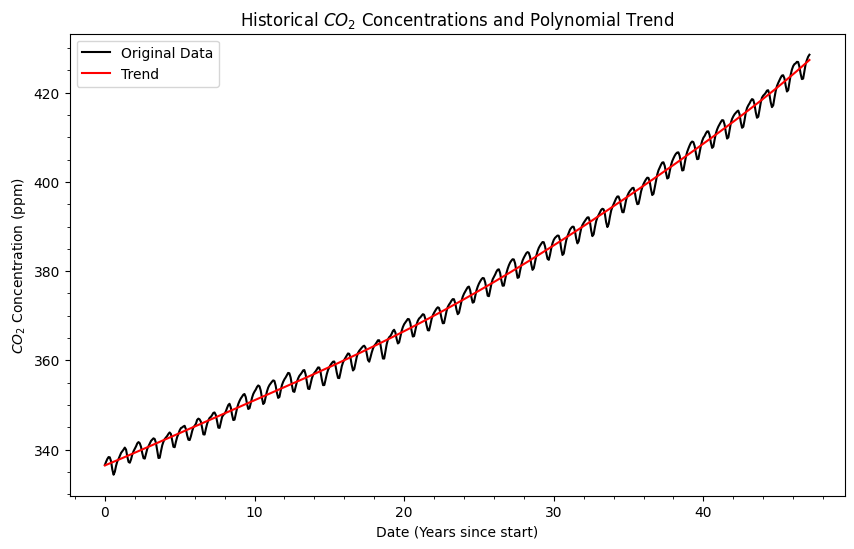

In [55]:
# --- Data Preparation ---
# Convert the 'dt' datetime column into a numerical array representing years since the start of the record
date_co2 = (df_CO2['dt'] - df_CO2['dt'].min()).dt.days / 365.25
date_co2 = date_co2.to_numpy()

# Extract the CO2 concentration values (ppm) as a numpy array
CO2_obs = df_CO2['average'].to_numpy()

# --- Polynomial Trend Fitting ---
# Define the degree of the polynomial to fit the long-term trend
order = 6

# Use np.polyfit to calculate the coefficients (pp) that minimize the squared error
co2_pp = np.polyfit(date_co2, CO2_obs, order)

# Evaluate the resulting polynomial at every time point to generate the trend line
co2_trend = np.polyval(co2_pp, date_co2)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(date_co2, CO2_obs, 'k', label='Original Data') # Plot the raw CO2 data in black
plt.plot(date_co2, co2_trend, 'r', label='Trend') # Plot the fitted polynomial trend in red

# Label the axes and improve the aesthetics
plt.title('Historical $CO_2$ Concentrations and Polynomial Trend')
plt.xlabel('Date (Years since start)')
plt.ylabel('$CO_2$ Concentration (ppm)')
plt.minorticks_on()
plt.legend()
plt.show()

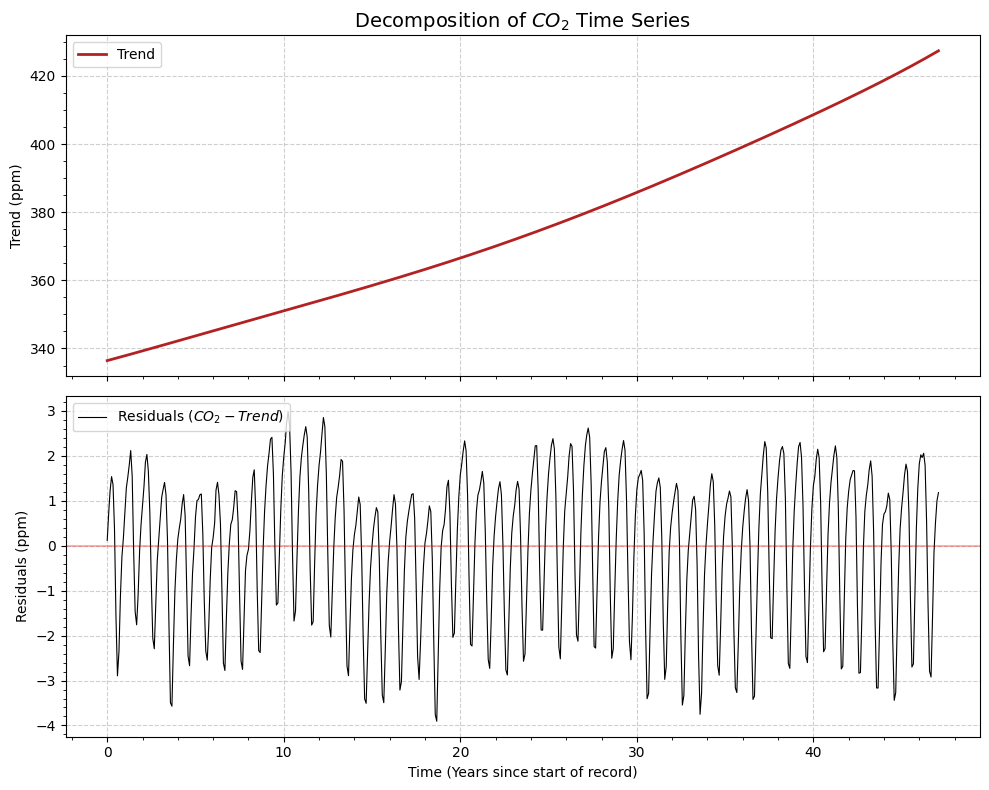

In [56]:
# --- Calculate Residuals ---
# The residuals represent the seasonal cycle and noise left after removing the trend
co2_residuals = CO2_obs - co2_trend

# --- Visualization: Trend and Residuals ---
# Create a figure with two vertical subplots sharing the same x-axis
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Long-term Polynomial Trend
axes[0].plot(date_co2, co2_trend, color='firebrick', lw=2, label='Trend')
axes[0].set_ylabel('Trend (ppm)')
axes[0].set_title('Decomposition of $CO_2$ Time Series', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].minorticks_on()

# Bottom Plot: Residuals (Seasonal cycle + noise)
axes[1].plot(date_co2, co2_residuals, color='black', lw=0.8, label='Residuals ($CO_2 - Trend$)')
axes[1].axhline(0, color='red', linestyle='-', alpha=0.3) # Add a zero baseline for reference
axes[1].set_ylabel('Residuals (ppm)')
axes[1].set_xlabel('Time (Years since start of record)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [57]:
def freq_spectrum(time, signal):
    """
    Calculates the frequency spectrum (amplitude) of a given signal using FFT.
    Handles non-uniform time series by interpolating onto a uniform grid.

    Parameters:
    time (array): Array of time values (e.g., years)
    signal (array): Array of signal values (e.g., CO2 concentration)

    Returns:
    x (array): Uniformly spaced time array used for FFT
    y (array): Signal interpolated onto the uniform grid
    freqs (array): Frequencies corresponding to the FFT values
    fft_vals (array): Complex results of the Real Fast Fourier Transform
    amplitude (array): Scaled peak amplitude for each frequency
    """
    n = len(time)

    # 1. Create a uniformly spaced time grid (required for standard FFT algorithms)
    x = np.linspace(np.min(time), np.max(time), n)

    # 2. Interpolate the original signal onto the uniform time grid
    y = np.interp(x, time, signal)

    # 3. Calculate the sample rate (points per unit of time)
    sample_rate = 1 / (x[1] - x[0])

    # 4. Perform the Real FFT (takes real input, returns positive frequency components)
    fft_vals = np.fft.rfft(y)

    # 5. Generate the frequency bins (cycles per unit of time)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 6. Calculate the amplitude: scale by (2/n) so peak height matches the sinusoid amplitude
    amplitude = (2 / n) * np.abs(fft_vals)

    # 7. Correct the DC component (frequency 0) which shouldn't be doubled by the rfft scale factor
    amplitude[0] /= 2

    return freqs, amplitude, fft_vals

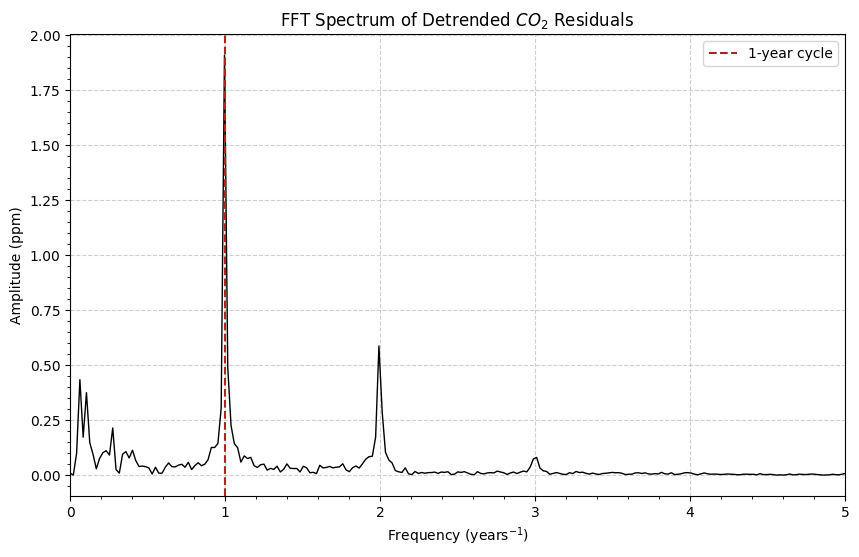

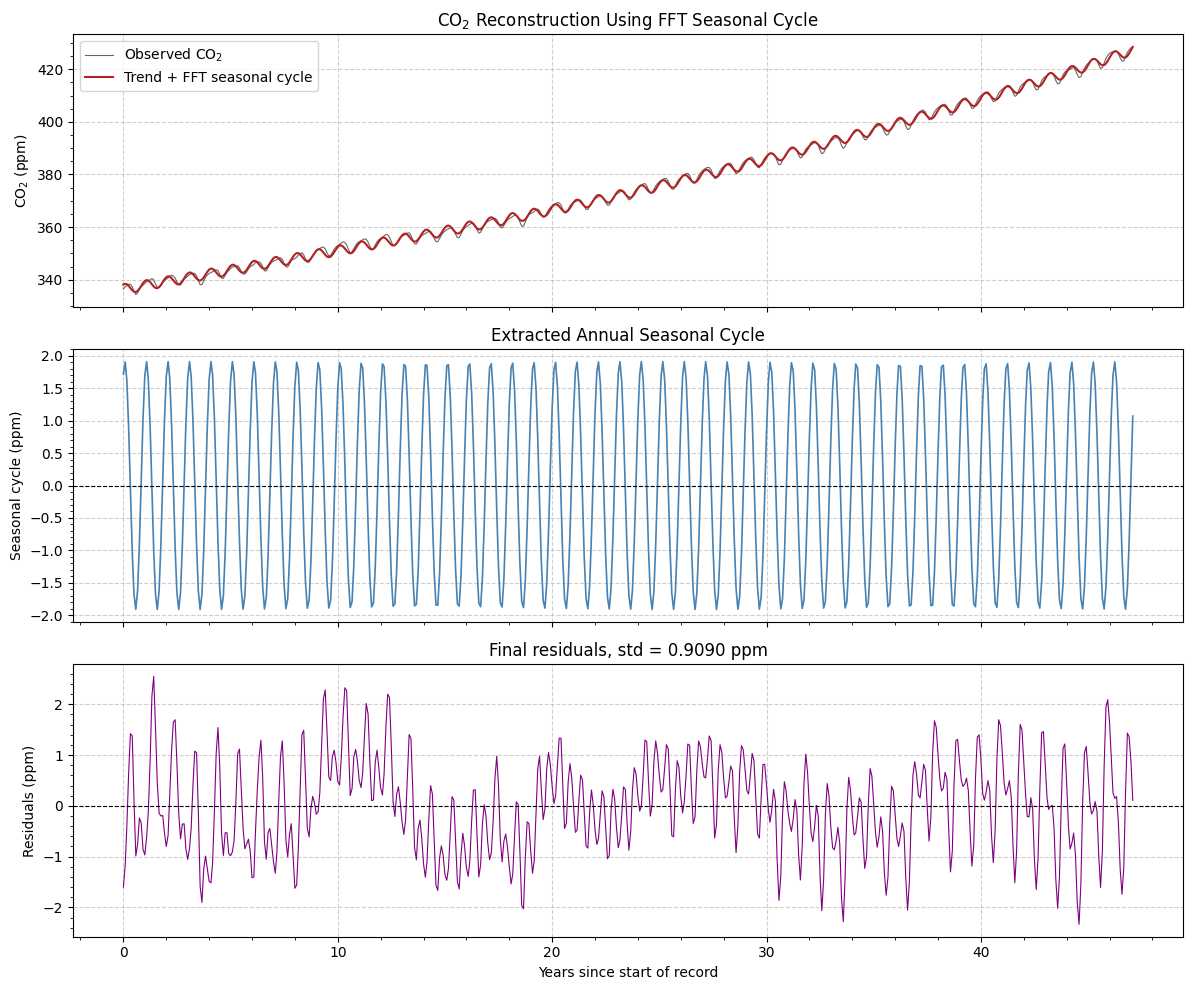

Seasonal CO2 expression from FFT:
CO2_seasonal(t) = 1.9096 * cos(2π * 0.9964 * t + -0.4540)

Full reconstructed CO2 expression:
CO2(t) = polynomial_trend(t) + 1.9096 * cos(2π * 0.9964 * t + -0.4540)


In [58]:
# --- Perform Spectral Analysis ---
# Calculate the frequency, phase, and amplitude of the detrended CO2 residuals using FFT
freqs_co2, amps_co2, fft_vals_co2 = freq_spectrum(date_co2, co2_residuals)

# --- Visualize the Frequency Spectrum ---
plt.figure(figsize=(10, 6))
plt.plot(freqs_co2, amps_co2, color='black', lw=1)

# Add a reference line for the 1-year (seasonal) cycle
plt.axvline(1, color='firebrick', linestyle='--', label='1-year cycle')
plt.xlabel('Frequency (years$^{-1}$)')
plt.ylabel('Amplitude (ppm)')
plt.title('FFT Spectrum of Detrended $CO_2$ Residuals')
plt.xlim(0, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend()
plt.show()

# --- Extract the Annual Cycle Components ---
# Find the index of the frequency bin closest to exactly 1.0 cycles/year
idx_annual = np.argmin(np.abs(freqs_co2 - 1.0))

# Extract the amplitude and phase angle (in radians) for the seasonal component
A_annual = amps_co2[idx_annual]
phi_annual = np.angle(fft_vals_co2[idx_annual])

# --- Reconstruct the Seasonal and Full Signals ---
# Create the seasonal cycle signal using the extracted amplitude and phase
co2_seasonal_fft = A_annual * np.cos(2 * np.pi * freqs_co2[idx_annual] * date_co2 + phi_annual)

# Combine the long-term polynomial trend with the new FFT-derived seasonal cycle
co2_reconstructed_fft = co2_trend + co2_seasonal_fft

# Calculate the remaining residuals (noise) after the full reconstruction
co2_final_residuals_fft = CO2_obs - co2_reconstructed_fft

# --- Visualize the Reconstruction Results ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Subplot A: Total CO2 Reconstruction vs Observations
axes[0].plot(date_co2, CO2_obs, color='black', lw=0.8, alpha=0.6, label='Observed CO$_2$')
axes[0].plot(date_co2, co2_reconstructed_fft, color='firebrick', lw=1.5, label='Trend + FFT seasonal cycle')
axes[0].set_ylabel('CO$_2$ (ppm)')
axes[0].set_title('CO$_2$ Reconstruction Using FFT Seasonal Cycle')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].minorticks_on()

# Subplot B: The isolated annual cycle component
axes[1].plot(date_co2, co2_seasonal_fft, color='steelblue', lw=1.2)
axes[1].axhline(0, color='black', linestyle='--', lw=0.8)
axes[1].set_ylabel('Seasonal cycle (ppm)')
axes[1].set_title('Extracted Annual Seasonal Cycle')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()

# Subplot C: Final residuals (ideally white noise centered at zero)
axes[2].plot(date_co2, co2_final_residuals_fft, color='purple', lw=0.8)
axes[2].axhline(0, color='black', linestyle='--', lw=0.8)
axes[2].set_ylabel('Residuals (ppm)')
axes[2].set_xlabel('Years since start of record')
axes[2].set_title(f'Final residuals, std = {co2_final_residuals_fft.std():.4f} ppm')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].minorticks_on()

plt.tight_layout()
plt.show()

# --- Summary Output ---
# Print the mathematical expressions derived from the analysis
print("Seasonal CO2 expression from FFT:")
print(
    f"CO2_seasonal(t) = {A_annual:.4f} * cos("
    f"2π * {freqs_co2[idx_annual]:.4f} * t + {phi_annual:.4f})"
)

print("\nFull reconstructed CO2 expression:")
print(
    "CO2(t) = polynomial_trend(t) "
    f"+ {A_annual:.4f} * cos(2π * {freqs_co2[idx_annual]:.4f} * t + {phi_annual:.4f})"
)

In [59]:
def CO2_growth_rate(t):
    """
    Calculates the CO2 concentration at time t by combining a long-term
    anthropogenic trend (polynomial) with a seasonal cycle (FFT-derived).

    Parameters:
    t (float or ndarray): Time in years since the start of the record.

    Returns:
    rate (float or ndarray): CO2 concentration in ppm.
    """
    # 1. Evaluate the polynomial trend at time t
    trend = np.polyval(co2_pp, t)

    # 2. Add the seasonal cycle using the amplitude (A_annual) and phase (phi_annual)
    # derived from the Fast Fourier Transform analysis.
    # The frequency is taken from the peak in the power spectrum (~1 year^-1).
    freq = freqs_co2[idx_annual]
    seasonal_cycle = A_annual * np.cos(2 * np.pi * freq * t + phi_annual)

    return trend + seasonal_cycle

In [60]:
#ΔF=OLR2−OLR1 ​=α⋅ln(C0/​CO2​​)

###Atmospheric Heat Capacity

In [61]:
# Calculate Heat Capacities for Atmospheric Layers
# Formula: Heat Capacity Atmosphere = (Specific heat capacity of dry air * pressure thickness of atmosphere) / gravity

# Specific heat capacity of dry air at constant pressure (J/kg/K)
Cp = 1004

# Pressure thickness of the upper atmospheric layer (Pa)
delta_p1 = 30000

# Pressure thickness of the lower atmospheric layer (Pa)
delta_p2 = 70000

# Acceleration due to gravity (m/s^2)
g = 9.81

# Calculate heat capacity for layer 1 (J/m^2 K)
Ca1 = (Cp * delta_p1) / g

# Calculate heat capacity for layer 2 (J/m^2 K)
Ca2 = (Cp * delta_p2) / g

# Display the calculated heat capacities
print(f"Ca1 = {Ca1:.4f} J/m^2 K")
print(f"Ca2 = {Ca2:.4f} J/m^2 K")

Ca1 = 3070336.3914 J/m^2 K
Ca2 = 7164118.2467 J/m^2 K


In [62]:
#Ca = Cp/g * integral dp (J/K*m^2) or Ca = integral of ro *cp*dz
#where ro(z) = atm density, cp = specific heat capacity of air, dz = vertical layer thickness
# cp = J/kg*K
# VIT = (K * kg/m^2)
# VIT/Ta = (kg/m^2) -> * Cp = (J/K*m^2)

#dp = -rogdz -> Ca = Cp/g * integral dp -> Ca = (Cp*delta p)/g
#Ca = F_atm_net/(dT/dt)

###Solar Insolation via FFT

In [63]:
def lowpass_filter(time, signal, cutoff):
    """
    Removes high-frequency noise from a signal using a Fast Fourier Transform (FFT).

    Parameters:
    time (array): Time values (e.g., years).
    signal (array): The data values to be filtered.
    cutoff (float): Frequency threshold (cycles/unit time). Components above this are removed.

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): The reconstructed low-frequency signal.
    """
    n = len(time)

    # 1. Create a uniform time grid (required for FFT) and interpolate the signal
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform Real FFT and calculate frequency bins
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Set amplitudes to zero for all frequencies above the cutoff
    fft_vals[freqs > cutoff] = 0.0

    # 4. Reconstruct the signal using the Inverse FFT
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))

    return x, filtered_signal


def highpass_filter(time, signal, cutoff):
    """
    Removes low-frequency trends or cycles from a signal.

    Parameters:
    time (array): Time values.
    signal (array): Data values.
    cutoff (list/tuple): Threshold for filtering; specifically uses cutoff[1].

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): The reconstructed high-frequency signal.
    """
    n = len(time)

    # 1. Interpolate onto uniform grid
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform FFT
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Set amplitudes to zero for frequencies below the specified threshold.
    # This isolates the fast-varying components of the signal.
    fft_vals[freqs < cutoff[1]] = 0.0

    # 4. Reconstruct
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))

    return x, filtered_signal


def bandpass_filter(time, signal, cutoff_range):
    """
    Isolates a specific frequency band (e.g., the 11-year solar cycle).

    Parameters:
    time (array): Time values.
    signal (array): Data values.
    cutoff_range (list): A [low, high] frequency range to keep.

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): Reconstructed signal containing only frequencies in range.
    """
    n = len(time)

    # 1. Interpolate onto uniform grid
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform FFT
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Zero out frequencies outside the [low, high] range
    fft_vals[(freqs < cutoff_range[0]) | (freqs > cutoff_range[1])] = 0.0

    # 4. Reconstruct filtered signal using Inverse FFT
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))
    return x, filtered_signal

In [64]:
# Extract the Total Solar Irradiance (TSI) values as a numpy array for numerical analysis
TSI = df_S['TSI'].values

# Create a time array ('age') representing years.
# np.arange(1, len(TSI) + 1) creates a sequence of days, which is then divided by 365.25.
age_TSI = np.arange(1, len(TSI) + 1) / 365.25

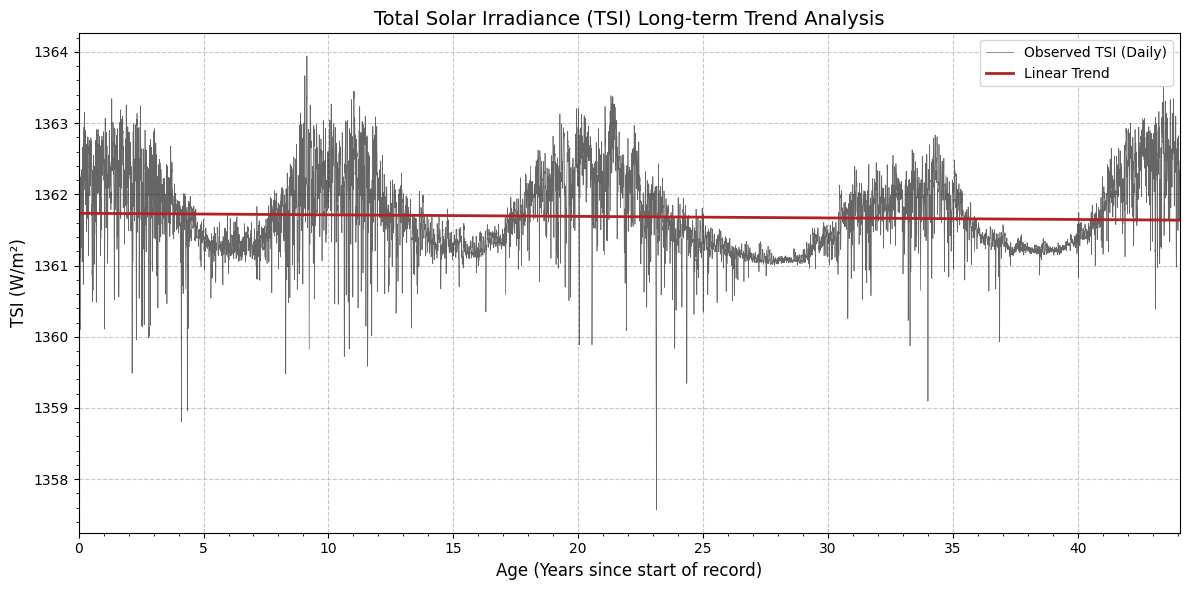

In [65]:
# Calculate a first-degree polynomial (linear) fit to identify the long-term trend
pp_TSI = np.polyfit(age_TSI, TSI, 1)

plt.figure(figsize=(12, 6))

# Plot raw TSI and the linear trend
plt.plot(age_TSI, TSI, color='black', lw=0.5, alpha=0.6, label='Observed TSI (Daily)')
plt.plot(age_TSI, np.polyval(pp_TSI, age_TSI), color='firebrick', lw=2, label='Linear Trend')
plt.title('Total Solar Irradiance (TSI) Long-term Trend Analysis', fontsize=14)
plt.xlabel('Age (Years since start of record)', fontsize=12)
plt.ylabel('TSI (W/m²)', fontsize=12)
plt.xlim([0, age_TSI.max()])
plt.grid(True, linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

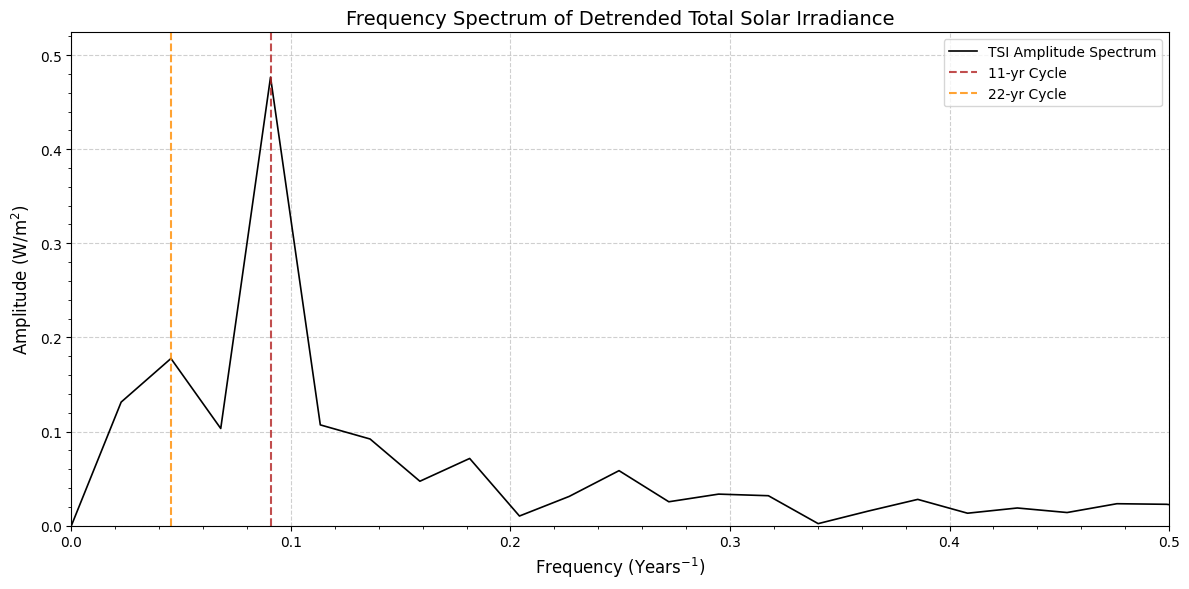

In [66]:
# --- Spectral Analysis of Detrended TSI ---
# Calculate the detrended data by subtracting the linear trend from the observations
detrend = TSI - np.polyval(pp_TSI, age_TSI)

# Compute the frequency spectrum (frequency and amplitude) using FFT
freqs, amps, fft_vals = freq_spectrum(age_TSI, detrend)

# --- Visualization Setup ---
plt.figure(figsize=(12, 6))
plt.plot(freqs, amps, color='black', lw=1.2, label='TSI Amplitude Spectrum')
plt.axvline(x=1/11, color='firebrick', ls='--', alpha=0.8, label='11-yr Cycle')
plt.axvline(x=1/22, color='darkorange', ls='--', alpha=0.8, label='22-yr Cycle')
plt.title('Frequency Spectrum of Detrended Total Solar Irradiance', fontsize=14)
plt.xlabel('Frequency (Years$^{-1}$)', fontsize=12)
plt.ylabel('Amplitude (W/m$^2$)', fontsize=12)
plt.xlim([0, 0.5])
plt.ylim([0, max(amps) * 1.1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

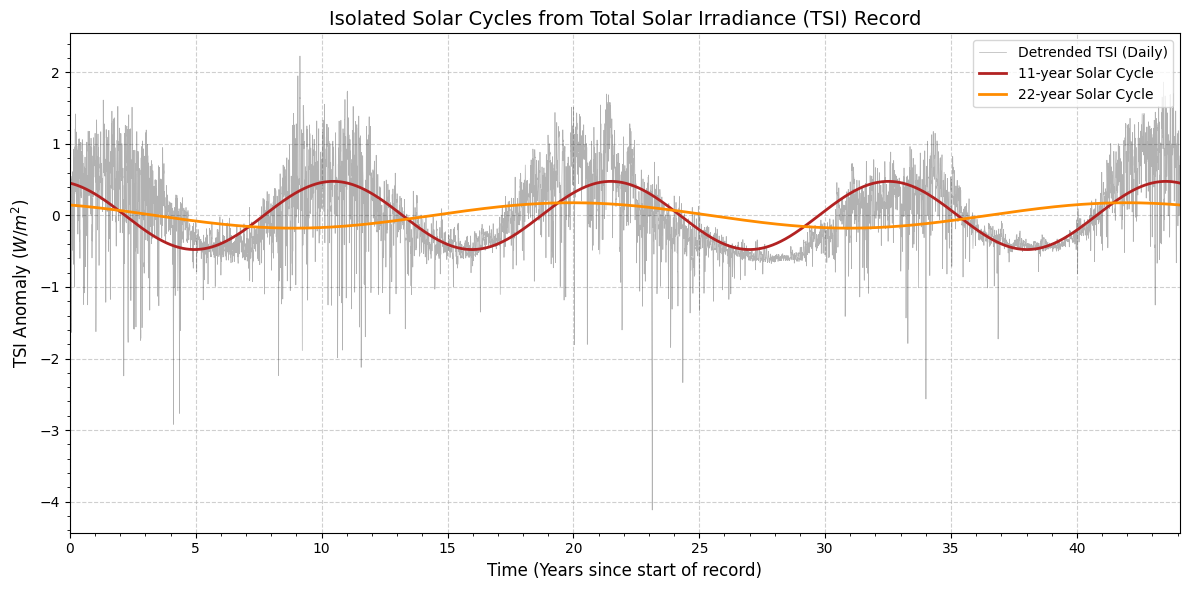

In [67]:
# --- Solar Cycle Isolation (11-yr and 22-yr) ---
# Define the frequency bands for isolation
# 11-year cycle corresponds to ~0.09 years^-1
# 22-year cycle corresponds to ~0.045 years^-1
x11, y11 = bandpass_filter(age_TSI, detrend, [0.08, 0.10])
x22, y22 = bandpass_filter(age_TSI, detrend, [0.03, 0.06])

# --- Visualization of Filtered TSI Anomalies ---
plt.figure(figsize=(12, 6))

# Plot the underlying detrended daily TSI data
plt.plot(age_TSI, detrend, color='black', alpha=0.3, lw=0.5, label='Detrended TSI (Daily)')

# Plot isolated cycles
plt.plot(x11, y11, color='firebrick', lw=2, label='11-year Solar Cycle')
plt.plot(x22, y22, color='darkorange', lw=2, label='22-year Solar Cycle')
plt.title('Isolated Solar Cycles from Total Solar Irradiance (TSI) Record', fontsize=14)
plt.xlabel('Time (Years since start of record)', fontsize=12)
plt.ylabel('TSI Anomaly ($W/m^2$)', fontsize=12)
plt.xlim([0, age_TSI.max()])
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend(frameon=True, loc='upper right')

plt.tight_layout()
plt.show()

In [68]:
   # S = S0 + A_cycle1 * np.sin(2 * np.pi * t / P_cycle1) + A_cycle2 * np.sin(2 * np.pi * t / P_cycle2)

In [69]:
# --- Calculate Baseline TSI and Amplitudes ---
S0 = df_S['TSI'].mean()
f11 = np.argmin(np.abs(freqs - 1/11))
f22 = np.argmin(np.abs(freqs - 1/22))
A11 = amps[f11]
A22 = amps[f22]

# --- Spectral Analysis (RFFT) ---
# Perform a Real Fast Fourier Transform (RFFT) on the interpolated detrended TSI data
fft_vals = np.fft.rfft(detrend)
# Calculate the frequencies corresponding to the FFT results
all_freqs = np.fft.rfftfreq(len(age_TSI), d=(age_TSI[1]-age_TSI[0]))

# --- Phase Extraction ---
# Extract the phase angle (in radians) for the 11-year and 22-year cycles
phi11 = np.angle(fft_vals[f11])
phi22 = np.angle(fft_vals[f22])

In [70]:
def Solar_Insolation(t):
    """
    Calculates the Total Solar Irradiance (TSI) at time t by reconstructing
    the 11-year and 22-year solar cycles derived from spectral analysis.

    Parameters:
    t (float or ndarray): Time in years.

    Returns:
    S (float or ndarray): Reconstructed TSI (W/m^2).
    """
    # Reconstruct the 11-year Schwabe cycle using extracted amplitude and phase
    cycle11 = A11 * np.cos(2*np.pi*t/11 + phi11)

    # Reconstruct the 22-year Hale cycle using extracted amplitude and phase
    cycle22 = A22 * np.cos(2*np.pi*t/22 + phi22)

    # Return the sum of the baseline irradiance (S0) and the two primary cycles
    return S0 + cycle11 + cycle22

Baseline S0  = 1361.6862 W/m²
Amplitude 11 = 0.4765 W/m²
Phase 11     = 0.3221 rad
Amplitude 22 = 0.1776 W/m²
Phase 22     = 0.6044 rad


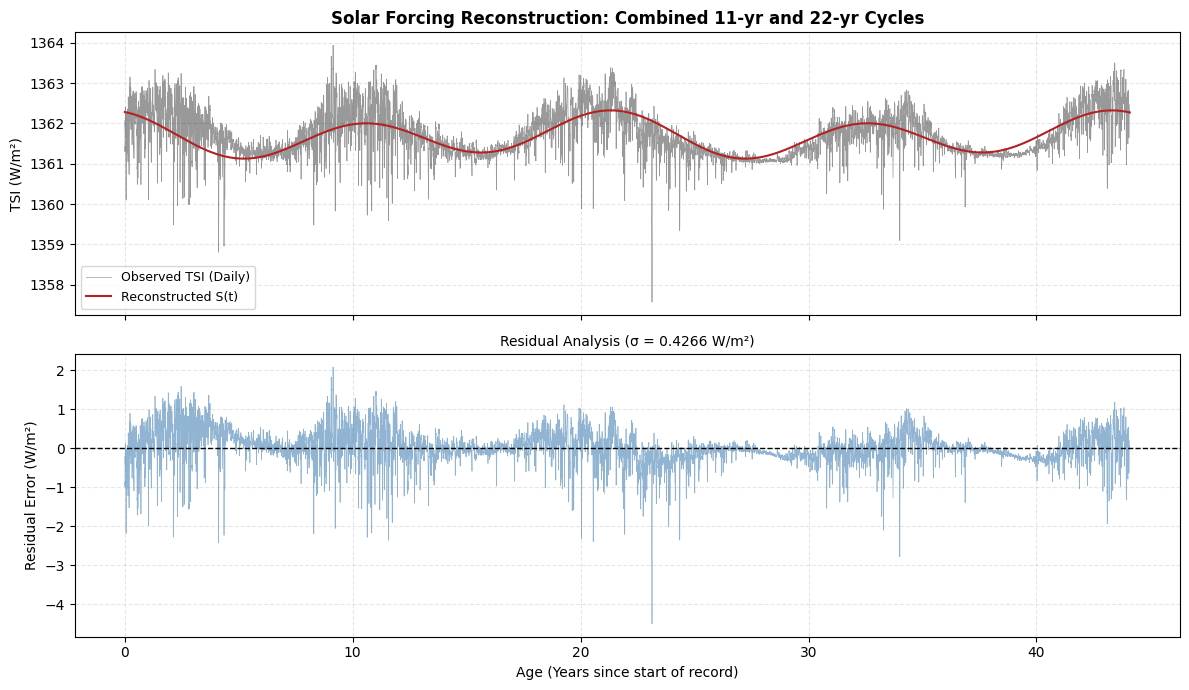

In [71]:
# --- Calculate Reconstructed Solar Forcing and Residuals ---
# Evaluate the solar insolation function over the time period
S = Solar_Insolation(age_TSI)
residuals = TSI - S

# --- Display Reconstructed Parameters ---
print(f"Baseline S0  = {S0:.4f} W/m²")
print(f"Amplitude 11 = {A11:.4f} W/m²")
print(f"Phase 11     = {phi11:.4f} rad")
print(f"Amplitude 22 = {A22:.4f} W/m²")
print(f"Phase 22     = {phi22:.4f} rad")

# --- Visualization: Solar Fit and Residual Analysis ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top Plot: Observed vs. Reconstructed Solar Forcing
axes[0].plot(age_TSI, TSI, color='black', lw=0.5, alpha=0.4, label='Observed TSI (Daily)')
axes[0].plot(age_TSI, S, color='firebrick', lw=1.5, label='Reconstructed S(t)')
axes[0].set_ylabel('TSI (W/m²)')
axes[0].set_title('Solar Forcing Reconstruction: Combined 11-yr and 22-yr Cycles', fontweight='bold')
axes[0].legend(fontsize=9, frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Bottom Plot: Residual Error
axes[1].plot(age_TSI, residuals, color='steelblue', lw=0.5, alpha=0.6)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_ylabel('Residual Error (W/m²)')
axes[1].set_xlabel('Age (Years since start of record)')
axes[1].set_title(f'Residual Analysis (σ = {residuals.std():.4f} W/m²)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

###Epsilon analytical and numerical (regression)

In [72]:
# --- Calculate Atmospheric Emissivity (Epsilon) ---
# The relationship between Surface Temperature (Ts) and Outgoing Longwave Radiation (OLR)
# is defined by: OLR = sigma * Ts^4 * (1 - epsilon/2)
# Rearranging to solve for epsilon: epsilon = 2 * (1 - OLR / (sigma * Ts^4))

# Ensure OLR values are positive for physical consistency
OLR_abs = np.abs(df_tnlwrf['avg_tnlwrf'])

# --- Derived Time Series for Epsilon ---
# Calculate epsilon at each time step using absolute surface temperature (Kelvin)
epsilon_ts = 2 * (1 - OLR_abs / (sigma * (df_Ts['Surface Temperature'] + 273.15)**4))

# --- Statistical Summary ---
# Compute the mean and standard deviation of the emissivity time series
epsilon = epsilon_ts.mean()
epsilon_std = epsilon_ts.std()

print(f"Calculated Emissivity (ε) = {epsilon:.4f} ± {epsilon_std:.4f}")

Calculated Emissivity (ε) = 0.8208 ± 0.0130


In [73]:
# --- Data Alignment and Radiative Flux Preparation ---

# Align OLR (from df_tnlwrf) and Surface Temperature (from df_Ts) datasets
# on the common 'dt' (datetime) column to ensure physical consistency at each time step.
# We drop any rows (NaNs) where data is not available in both sets.
df_aligned = pd.merge(
    df_tnlwrf[['dt', 'avg_tnlwrf']],
    df_Ts[['dt', 'Surface Temperature']],
    on='dt'
).dropna()

# --- Variable Extraction ---

# Extract the absolute value of the net longwave radiation flux (OLR)
OLR = np.abs(df_aligned['avg_tnlwrf'])

# Calculate the total blackbody radiation emitted by the surface (sigma * Ts^4)
# Note: Surface Temperature is converted from Celsius to Kelvin by adding 273.15
radiated = sigma * (df_aligned['Surface Temperature'] + 273.15)**4

In [74]:
# epsilon = 2 * (1 - OLR / (sigma * Ts^4))
# Rearranging to solve with regression: radiated-OLR = (epsilon/2)*radiated

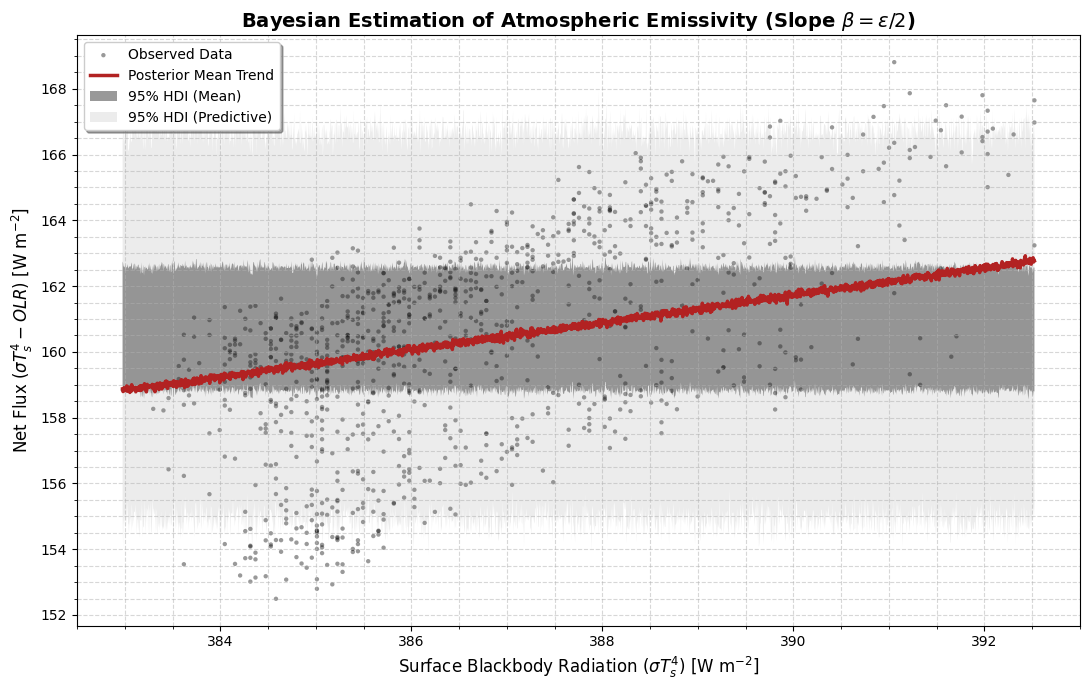

In [75]:
# --- Bayesian Regression for Atmospheric Emissivity ---

# Create a DataFrame for modeling:
# 'y' is the net flux (Radiated - OLR), 'x' is the surface blackbody radiation
data = pd.DataFrame({"y": radiated - OLR, "x": radiated})

# --- Model Definition and Fitting ---
# Define a Bayesian linear model passing through the origin (y ~ 0 + x)
model_linear = bmb.Model("y ~ 0+x", data)
idata_linear = model_linear.fit(progressbar=False)

# --- Posterior Predictions ---
# Generate a dense range of x-values for smooth plotting
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Generate predictions for the mean (response_params) and the full posterior predictive distribution (response)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# --- Draw and Reshape Posterior Samples ---
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# --- Statistical Uncertainty Calculations ---
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# --- Visualization ---
plt.figure(figsize=(11, 7))

# Plot observed data points with reduced alpha for density visualization
plt.scatter(data['x'], data['y'], color='black', s=10, alpha=0.4, label="Observed Data", edgecolors='none')

# Plot the central posterior mean trend
plt.plot(x_range, posterior_mean, color="firebrick", lw=2.5, label="Posterior Mean Trend")

# Shade the 95% HDI for the mean (uncertainty in the slope)
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.4,
    color="black",
    label="95% HDI (Mean)",
    edgecolor=None
)

# Shade the 95% HDI for the predictive distribution (expected range of new data)
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.15,
    color="gray",
    label="95% HDI (Predictive)",
    edgecolor=None
)

# Formatting labels and appearance
plt.xlabel(r'Surface Blackbody Radiation ($\sigma T_s^4$) [W m$^{-2}$]', fontsize=12)
plt.ylabel(r'Net Flux ($\sigma T_s^4 - OLR$) [W m$^{-2}$]', fontsize=12)
plt.title(r'Bayesian Estimation of Atmospheric Emissivity (Slope $\beta = \epsilon/2$)', fontsize=14, fontweight='bold')

plt.legend(loc='upper left', frameon=True, shadow=True)
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [76]:
# --- Post-Processing: Atmospheric Emissivity (epsilon) Derivation ---

# Extract the posterior samples for the slope 'x' from the inference data object
# In our model (y ~ 0 + x), the slope beta represents epsilon/2
beta = idata_linear.posterior["x"].values.flatten()

# Convert the slope samples back into emissivity (epsilon) samples
# Since beta = epsilon / 2, then epsilon = 2 * beta
epsilon_samples = 2 * beta

# Calculate the central estimate (mean) of the emissivity from the posterior distribution
epsilon_mean = epsilon_samples.mean()

# Compute the 95% Highest Density Interval (HDI)
# This provides the range within which the true value of epsilon lies with 95% probability
epsilon_hdi = az.hdi(epsilon_samples, prob=0.95)

# Output the results for integration into the Energy Balance Model (EBM)
print(f"Calculated Emissivity (epsilon) = {epsilon_mean:.4f}")
print(f"95% HDI: [{epsilon_hdi[0]:.4f}, {epsilon_hdi[1]:.4f}]")

Calculated Emissivity (epsilon) = 0.8293
95% HDI: [0.8285, 0.8302]


###Gamma1 and Gamma2 analytical and numerical (regression)

In [77]:
# --- Heat Exchange Coefficient (Gamma) Derivations ---

# Gamma1 (Surface-to-Deep Ocean exchange):
# Derived from the energy balance of the first deep ocean layer (0-2000m):
# C_d1(dTd1/dt) = gamma1(Ts - Td1) - gamma2(Td1 - Td2)
# Rearranging for gamma1:
# gamma1 = [C_d1(dTd1/dt) + gamma2(Td1 - Td2)] / (Ts - Td1)

# Gamma2 (Deep-to-Abyssal Ocean exchange):
# Derived from the energy balance of the second deep ocean layer (2000-6000m):
# C_d2(dTd2/dt) = gamma2(Td1 - Td2)
# Rearranging for gamma2:
# gamma2 = [C_d2(dTd2/dt)] / (Td1 - Td2)

# --- Reference Temperatures (Baseline Climatology) ---
# These constants convert temperature anomalies into absolute Kelvin (K)
# Td1_ref: Approximate 1981-2010 mean temperature for the 0-2000m ocean layer
Td1_ref = 275.0

# Td2_ref: Approximate 1981-2010 mean temperature for the 2000-6000m ocean layer
Td2_ref = 274.5

In [78]:
# --- Absolute Temperature Conversion Constants ---
# Td1_ref: Approximate 1981-2010 mean absolute temperature for the 0-2000m layer (K)
# Td2_ref: Approximate 1981-2010 mean absolute temperature for the 2000-6000m layer (K)
Td1_ref = 275.0
Td2_ref = 274.5

# --- Data Alignment ---
# Align the surface temperature record with the upper deep ocean (Td1) record
df_aligned = pd.merge(
    df_Ts[['dt', 'Surface Temperature']],
    df_Td1[['dt', 'Temperature']],
    on='dt'
)

# Further align with the abyssal ocean (Td2) record
# Suffixes are added to distinguish the 'Temperature' columns from different depths
df_aligned = pd.merge(
    df_aligned,
    df_Td2[['dt', 'Temperature']],
    on='dt',
    suffixes=('_Td1', '_Td2')
).dropna()

# --- Unit Conversion ---
# Ts: Convert surface temperature from Celsius to absolute Kelvin
Ts = df_aligned['Surface Temperature'] + 273.15

# Td1/Td2: Add reference climatologies to the anomalies to get absolute Kelvin
Td1 = df_aligned['Temperature_Td1'] + Td1_ref
Td2 = df_aligned['Temperature_Td2'] + Td2_ref

In [79]:
# --- Temperature Gradient Calculation ---
# Calculate derivatives (dT/dt) in Kelvin per second.
# We use the central difference method (np.gradient) for the monthly time-series.
dTd2_dt = np.gradient(Td2, seconds_per_year / 12)
dTd1_dt = np.gradient(Td1, seconds_per_year / 12)

# --- Gamma 2 (Deep Ocean Exchange) Derivation ---
# Based on the energy balance for the abyssal layer (h2):
# C_d2 * (dTd2/dt) = gamma2 * (Td1 - Td2)
# We rearrange to solve for the mean coefficient gamma2 (W/m^2/K).
gamma2_series = (C_d2 * dTd2_dt) / (Td1 - Td2)
gamma2_final = gamma2_series.mean()

# --- Gamma 1 (Surface-to-Deep Exchange) Derivation ---
# Based on the energy balance for the upper deep ocean layer (h1):
# C_d1 * (dTd1/dt) = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)
# Rearranging to isolate gamma1:
gamma1_series = (C_d1 * dTd1_dt + gamma2_final * (Td1 - Td2)) / (Ts - Td1)
gamma1_final = gamma1_series.mean()

# --- Results Summary ---
print(f"Analytical gamma2: {gamma2_final:.4f} W/m^2/K")
print(f"Analytical gamma1: {gamma1_final:.4f} W/m^2/K")

Analytical gamma2: 0.5100 W/m^2/K
Analytical gamma1: 0.1036 W/m^2/K


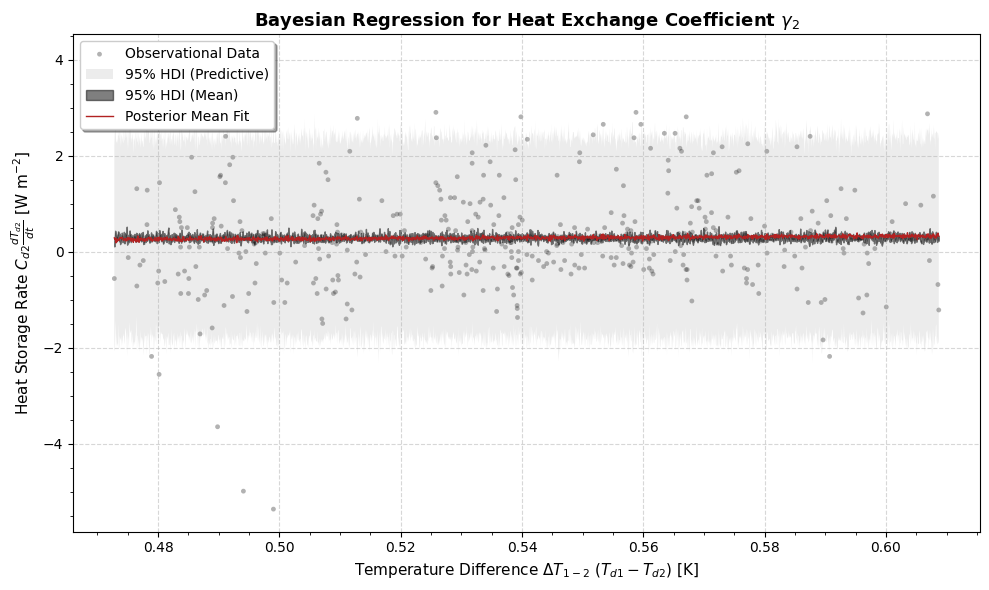

In [80]:
# --- Bayesian Regression for Gamma 2 (Deep-to-Abyssal Exchange) ---

# 1. Prepare data: y is the heat storage rate of the abyssal layer, x is the temp gradient
data = pd.DataFrame({"y": C_d2 * np.gradient(Td2, seconds_per_year/12), "x": Td1 - Td2})

# 2. Fit Bayesian linear model through the origin
# The slope of this line represents the heat exchange coefficient gamma2 (W/m^2/K)
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

# 3. Generate predictions for visualization
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Predict mean (response_params) and full distribution (response)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# 4. Extract posterior draws and reshape
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# 5. Compute summary statistics (Mean and 95% HDI)
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# 6. Aesthetic Visualization
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(data['x'], data['y'], color='black', s=12, alpha=0.3, label="Observational Data", edgecolors='none', zorder=1)

# --- Plot uncertainty bands (HDI) ---
# Plot Predictive HDI
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.15,
    color="gray",
    label="95% HDI (Predictive)",
    edgecolor=None,
)

# Plot Mean HDI
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.5,
    color="black",
    label="95% HDI (Mean)",
)

# Plot posterior mean line
plt.plot(x_range, posterior_mean, color="firebrick", lw=1, label="Posterior Mean Fit")

# Formatting
plt.xlabel(r'Temperature Difference $\Delta T_{1-2}$ ($T_{d1} - T_{d2}$) [K]', fontsize=11)
plt.ylabel(r'Heat Storage Rate $C_{d2} \frac{dT_{d2}}{dt}$ [W m$^{-2}$]', fontsize=11)
plt.title(r'Bayesian Regression for Heat Exchange Coefficient $\gamma_2$', fontsize=13, fontweight='bold')

plt.legend(frameon=True, shadow=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [81]:
# --- Posterior Extraction for Deep Ocean Heat Exchange Coefficient (gamma2) ---

# Extract the posterior samples for the slope 'x' from the inference object.
# In the regression y ~ 0 + x (where y is heat storage and x is temp gradient),
# the slope 'beta' represents the physical coefficient gamma2.
beta = idata_linear.posterior["x"].values.flatten()

# Map the posterior draws to our physical parameter samples
gamma2_samples = beta

# Calculate the expected value (mean) of the coefficient from the posterior distribution
gamma2_mean = gamma2_samples.mean()

# Compute the 95% Highest Density Interval (HDI) using ArviZ.
# This defines the most credible range for gamma2 given the observational data.
gamma2_hdi = az.hdi(gamma2_samples, prob=0.95)

# Display the final derived parameter and its associated uncertainty
print(f"gamma2 = {gamma2_mean:.4f}, 95% HDI [{gamma2_hdi[0]:.4f}, {gamma2_hdi[1]:.4f}]")

gamma2 = 0.5310, 95% HDI [0.3485, 0.7482]


In [82]:
# C_d1 * dTd1/dt = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)

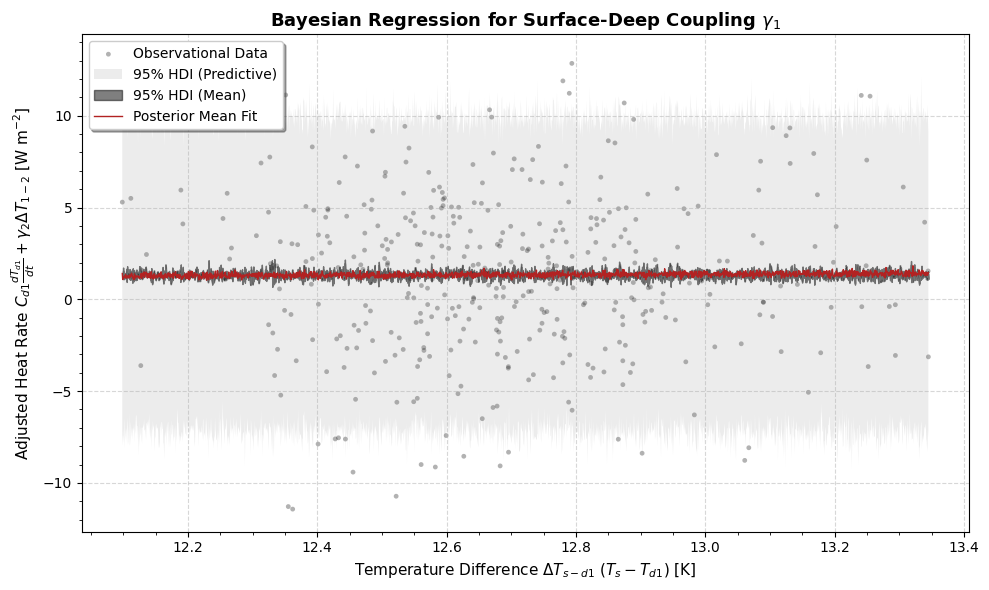

In [83]:
# --- Bayesian Regression for Surface-to-Deep Heat Exchange (Gamma 1) ---

# 1. Prepare data based on the energy balance for the upper deep ocean (layer 1):
# C_d1 * (dTd1/dt) = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)
# To solve for gamma1 using a slope, we define:
# y = C_d1 * dTd1/dt + gamma2_mean * (Td1 - Td2)
# x = Ts - Td1
# The slope of y ~ x then represents gamma1.
data = pd.DataFrame({
    "y": C_d1 * np.gradient(Td1, seconds_per_year/12) + gamma2_mean * (Td1 - Td2),
    "x": Ts - Td1
})

# 2. Fit Bayesian Model through the origin
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

# 3. Generate predictions for visualization
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Predict the mean (regression line) and the full posterior predictive (observations)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# 4. Extract and reshape posterior draws
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# 5. Compute summary statistics (Mean and 95% HDI)
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# 6. Visualization setup
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(data['x'], data['y'], color='black', s=12, alpha=0.3, label="Observational Data", edgecolors='none')

# Shade the Predictive HDI (Aleatoric uncertainty / expected noise in data)
plt.fill_between(
    x_range, hdi_pps[:, 0], hdi_pps[:, 1],
    alpha=0.15, color="gray", label="95% HDI (Predictive)", edgecolor=None,)

# Shade the Mean HDI (Epistemic uncertainty / precision of the gamma1 estimate)
plt.fill_between(
    x_range, hdi_mean[:, 0], hdi_mean[:, 1],
    alpha=0.5, color="black", label="95% HDI (Mean)")

# Plot the central posterior mean trend
plt.plot(x_range, posterior_mean, color="firebrick", lw=1, label="Posterior Mean Fit", zorder=4)

# Labeling and Formatting
plt.xlabel(r'Temperature Difference $\Delta T_{s-d1}$ ($T_s - T_{d1}$) [K]', fontsize=11)
plt.ylabel(r'Adjusted Heat Rate $C_{d1} \frac{dT_{d1}}{dt} + \gamma_2 \Delta T_{1-2}$ [W m$^{-2}$]', fontsize=11)
plt.title(r'Bayesian Regression for Surface-Deep Coupling $\gamma_1$', fontsize=13, fontweight='bold')

plt.legend(frameon=True, shadow=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [84]:
# --- Posterior Extraction for Surface-Deep Heat Exchange (gamma1) ---

# Extract the posterior samples for the slope 'x' from the inference object.
# In the regression y ~ 0 + x (where y is adjusted heat rate and x is temp gradient),
# the slope 'beta' represents the physical coefficient gamma1.
beta_gamma1 = idata_linear.posterior["x"].values.flatten()

# Map the posterior draws to our physical parameter samples
gamma1_samples = beta_gamma1

# Calculate the expected value (mean) of the coefficient from the posterior distribution
gamma1_mean = gamma1_samples.mean()

# Compute the 95% Highest Density Interval (HDI) using ArviZ.
# This defines the most credible range for gamma1 given the observational data.
gamma1_hdi = az.hdi(gamma1_samples, prob=0.95)

# Display the final derived parameter and its associated uncertainty
print(f"gamma1 = {gamma1_mean:.4f} W m⁻² K⁻¹")
print(f"95% HDI: [{gamma1_hdi[0]:.4f}, {gamma1_hdi[1]:.4f}]")

gamma1 = 0.1051 W m⁻² K⁻¹
95% HDI: [0.0719, 0.1378]


###Albedo

Best-fit albedo parameters:
alpha_min = 0.2762
alpha_max = 0.6830
T_ice    = 267.60 K (-5.55 °C)
delta_T  = 10.66 K


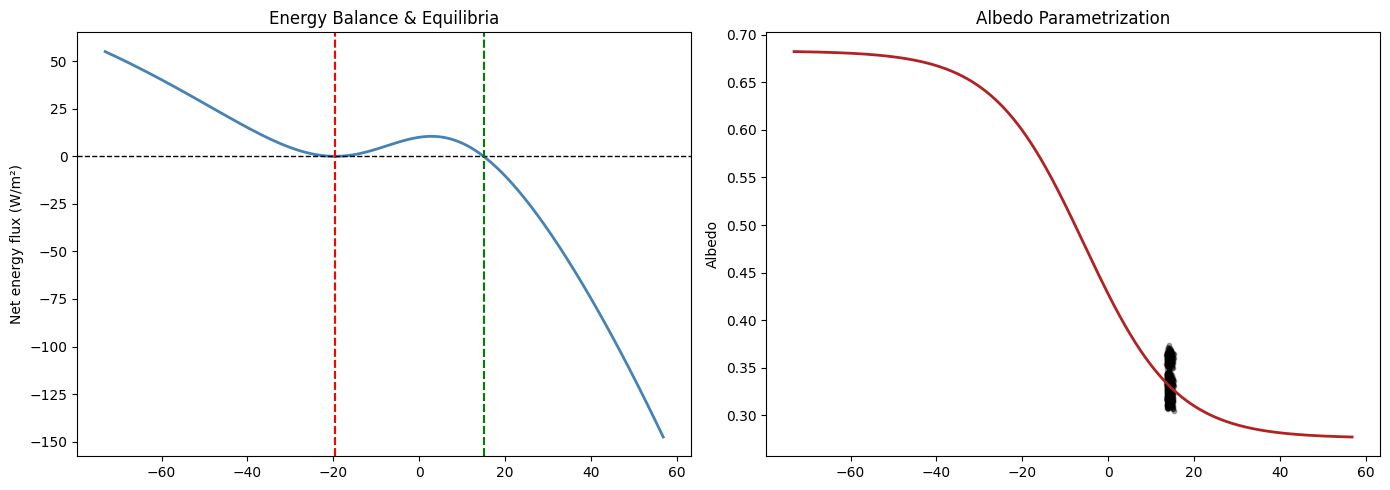

In [85]:
from scipy.optimize import differential_evolution

# ============================================================
# 1. OBSERVATIONAL DATA PREPARATION
# ============================================================
# We align multiple ERA5 and GISS datasets on the 'dt' column to create a
# consistent training set for albedo vs. temperature.

df_albedo = pd.merge(
    df_tnswrf[['dt', 'avg_tnswrf']],
    df_Ts[['dt', 'Surface Temperature']],
    on='dt'
).dropna()

df_albedo = pd.merge(
    df_albedo,
    df_tdswrf[['dt', 'avg_tdswrf']],
    on='dt'
).dropna()

# Extract numpy arrays and convert Ts to Kelvin
Ts_obs = df_albedo['Surface Temperature'].to_numpy() + 273.15
# Calculate observed albedo from Net and Downward Shortwave fluxes
alpha_obs = 1 - (np.abs(df_albedo['avg_tnswrf']) / df_albedo['avg_tdswrf'])

# ============================================================
# 2. MODEL DEFINITIONS
# ============================================================

Ts_range = np.linspace(200, 330, 5000)
T_modern = 288.15

def albedo_func(Ts, alpha_min, alpha_max, T_ice, delta_T):
    """Logistic function representing the temperature-dependent planetary albedo."""
    return alpha_min + (alpha_max - alpha_min) / (
        1 + np.exp((Ts - T_ice) / delta_T)
    )

def net_energy_flux(Ts, alpha_min, alpha_max, T_ice, delta_T):
    """Calculates SW_absorbed - OLR to find energy balance (F=0)."""
    alpha = albedo_func(Ts, alpha_min, alpha_max, T_ice, delta_T)
    SW_absorbed = (1 - alpha) * S0 / 4
    OLR = (1 - epsilon_mean / 2) * sigma * Ts**4
    return SW_absorbed - OLR

def find_equilibria(Ts_range, F):
    """Identifies zero-crossings in the flux and determines their stability."""
    sign_changes = np.where(np.diff(np.sign(F)))[0]
    equilibria = []

    for idx in sign_changes:
        # Linear interpolation for precise crossing point
        T_eq = Ts_range[idx] - F[idx] * (
            Ts_range[idx+1] - Ts_range[idx]
        ) / (F[idx+1] - F[idx])

        # Stable if slope of net flux is negative at crossing (F drops from + to -)
        stable = F[idx] > 0
        equilibria.append((T_eq, stable))

    return equilibria

# ============================================================
# 3. OBJECTIVE FUNCTION FOR OPTIMIZATION
# ============================================================

def objective(params):
    """
    Multi-constraint objective function for Differential Evolution.
    Minimizes albedo error while enforcing a specific EBM structure.
    """
    alpha_min, alpha_max, T_ice, delta_T = params

    # Penalty: Physical constraint (albedo must decrease with T)
    if alpha_max <= alpha_min:
        return 1e9

    # Component 1: Albedo Error (MSE vs. Observations)
    alpha_pred = albedo_func(Ts_obs, alpha_min, alpha_max, T_ice, delta_T)
    albedo_error = np.mean((alpha_obs - alpha_pred)**2)

    # Component 2: Structural Constraints
    # We require the model to exhibit a 'Snowball Earth' state, an unstable
    # transition, and a stable 'Modern Earth' state.
    F = net_energy_flux(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
    equilibria = find_equilibria(Ts_range, F)

    if len(equilibria) != 3:
        return albedo_error + 1e6 # Large penalty if not exactly 3 states

    cold_eq, mid_eq, warm_eq = equilibria
    correct_structure = (cold_eq[1] and not mid_eq[1] and warm_eq[1])

    if not correct_structure:
        return albedo_error + 1e6

    # Component 3: Climate Reality Constraint
    # The warm stable equilibrium MUST be near the observed modern temperature.
    warm_eq_error = ((warm_eq[0] - T_modern) / 5.0)**2

    # Component 4: Weak Priors
    # Gently guide parameters toward physically plausible values.
    prior_error = 0
    prior_error += ((alpha_min - 0.25) / 0.08)**2 * 0.01
    prior_error += ((alpha_max - 0.65) / 0.15)**2 * 0.01
    prior_error += ((T_ice - 265) / 10)**2 * 0.01
    prior_error += ((delta_T - 10) / 5)**2 * 0.01

    return albedo_error + warm_eq_error + prior_error

# ============================================================
# 4. OPTIMIZATION EXECUTION
# ============================================================

bounds = [
    (0.10, 0.35),   # alpha_min bounds
    (0.45, 0.85),   # alpha_max bounds
    (245, 285),     # T_ice (transition center) bounds
    (2, 25)         # delta_T (transition width) bounds
]

# Use Differential Evolution for global search (robust to local minima)
result = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    tol=1e-7,
    polish=True
)

alpha_min_fit, alpha_max_fit, T_ice_fit, delta_T_fit = result.x

# Print Summary
print("Best-fit albedo parameters:")
print(f"alpha_min = {alpha_min_fit:.4f}")
print(f"alpha_max = {alpha_max_fit:.4f}")
print(f"T_ice    = {T_ice_fit:.2f} K ({T_ice_fit - 273.15:.2f} °C)")
print(f"delta_T  = {delta_T_fit:.2f} K")

# Update global variables for use in subsequent simulation cells
alpha_min, alpha_max, T_ice, delta_T = result.x

# ============================================================
# 5. DIAGNOSTIC VISUALIZATION
# ============================================================

F_best = net_energy_flux(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
alpha_curve = albedo_func(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
equilibria = find_equilibria(Ts_range, F_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Energy Balance
axes[0].plot(Ts_range - 273.15, F_best, color='steelblue', lw=2)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].axvline(T_modern - 273.15, color='black', ls=':', label='Modern Earth')
for T_eq, stable in equilibria:
    axes[0].axvline(T_eq - 273.15, color='green' if stable else 'red', ls='--')
axes[0].set_title('Energy Balance & Equilibria')
axes[0].set_ylabel('Net energy flux (W/m²)')

# Plot B: Albedo Curve Fit
axes[1].scatter(Ts_obs - 273.15, alpha_obs, s=10, alpha=0.3, color='black', label='Observations')
axes[1].plot(Ts_range - 273.15, alpha_curve, color='firebrick', lw=2, label='Fitted Model')
axes[1].set_title('Albedo Parametrization')
axes[1].set_ylabel('Albedo')

plt.tight_layout()
plt.show()

In [86]:
from scipy.optimize import differential_evolution
import arviz as az

n_bootstrap = 50   # increase to 500+ for publication quality
n_obs = len(Ts_obs)

# Storage
boot_params = np.zeros((n_bootstrap, 4))
# cols: alpha_min, alpha_max, T_ice, delta_T

print(f"Running {n_bootstrap} bootstrap resamples...")
for b in range(n_bootstrap):
    if b % 25 == 0:
        print(f"  {b}/{n_bootstrap}")

    # Resample observations with replacement
    idx        = np.random.choice(n_obs, n_obs, replace=True)
    Ts_boot    = Ts_obs[idx]
    alpha_boot = alpha_obs.values[idx]

    # Redefine objective using bootstrap sample
    def objective_boot(params):
        a_min, a_max, T_i, dT = params
        if a_max <= a_min:
            return 1e9
        alpha_pred  = albedo_func(Ts_boot, a_min, a_max, T_i, dT)
        albedo_error = np.mean((alpha_boot - alpha_pred)**2)
        F           = net_energy_flux(Ts_range, a_min, a_max, T_i, dT)
        equilibria  = find_equilibria(Ts_range, F)
        if len(equilibria) != 3:
            return albedo_error + 1e6
        cold_eq, mid_eq, warm_eq = equilibria
        if not (cold_eq[1] and not mid_eq[1] and warm_eq[1]):
            return albedo_error + 1e6
        warm_eq_error = ((warm_eq[0] - T_modern) / 5.0)**2
        prior_error   = (((a_min-0.25)/0.08)**2 + ((a_max-0.65)/0.15)**2
                        + ((T_i-265)/10)**2 + ((dT-10)/5)**2) * 0.01
        return albedo_error + warm_eq_error + prior_error

    result_b = differential_evolution(
        objective_boot, bounds=bounds, seed=b, tol=1e-6, polish=True,
        maxiter=50   # fewer iterations per bootstrap for speed
    )
    boot_params[b] = result_b.x

# ── Summarise distributions ───────────────────────────────────────────────────
param_names = ['alpha_min', 'alpha_max', 'T_ice', 'delta_T']
for j, name in enumerate(param_names):
    samples = boot_params[:, j]
    hdi     = az.hdi(samples, prob=0.95)
    print(f"{name:12s}: mean={samples.mean():.4f}  "
          f"std={samples.std():.4f}  "
          f"95% HDI [{hdi[0]:.4f}, {hdi[1]:.4f}]")

# Store as named arrays for Monte Carlo
alpha_min_samples = boot_params[:, 0]
alpha_max_samples = boot_params[:, 1]
T_ice_samples     = boot_params[:, 2]
delta_T_samples   = boot_params[:, 3]

Running 50 bootstrap resamples...
  0/50
  25/50
alpha_min   : mean=0.2769  std=0.0018  95% HDI [0.2744, 0.2802]
alpha_max   : mean=0.6832  std=0.0027  95% HDI [0.6797, 0.6881]
T_ice       : mean=267.5400  std=0.2713  95% HDI [267.0301, 268.0124]
delta_T     : mean=10.6104  std=0.1359  95% HDI [10.4098, 10.8345]


####Brute force Least squares

In [87]:
# Define the range of possible values for the ice temperature (T_ice) and transition width (delta_T)
# These ranges are used in a brute-force search to find the best-fit albedo parameters.
#T_ice_values = np.linspace(250, 280, 200) # Ice temperature in Kelvin (e.g., 250K to 280K)
#delta_T_values = np.linspace(5, 25, 100) # Temperature range for the albedo transition in Kelvin

# -----------------------------------------------------------------------------
# Data Preparation: Merge relevant datasets for albedo model fitting
# -----------------------------------------------------------------------------
# Merge surface temperature (df_Ts) and forecast albedo (df_FAL)
#df_albedo = pd.merge(
    #df_FAL[['dt', 'fal']],
    #df_Ts[['dt', 'Surface Temperature']],
    #on='dt'
#).dropna() # Drop rows with missing values after merging

# Extract observed surface temperatures (Ts_obs) and convert to Kelvin
#Ts_obs = df_albedo['Surface Temperature'].to_numpy() + 273.15

# Extract observed albedo (alpha_obs) using 'fal' (fractional albedo).
# The commented-out line shows an alternative calculation using net and downward shortwave radiation.
#alpha_obs = df_albedo['fal'] #1 - (np.abs(df_albedo['avg_tnswrf']) / df_albedo['avg_tdswrf'])

# -----------------------------------------------------------------------------
# Brute-Force Search for Optimal Ice-Albedo Feedback Parameters
# -----------------------------------------------------------------------------

# Initialize variables to store the best parameters found and the corresponding error
#best_error = np.inf # Start with an infinitely large error
#T_ice = None         # Optimal ice temperature
#delta_T = None       # Optimal transition width

# Loop through all combinations of T_ice and delta_T values
#for T_ice_test in T_ice_values:
    #for delta_T_test in delta_T_values:

        # Calculate the modeled albedo (alpha_model) using the current test parameters
        # This uses a logistic function to represent the albedo's dependence on surface temperature.
        #alpha_model = alpha_min + (alpha_max - alpha_min) / (
         #   1 + np.exp((Ts_obs - T_ice_test) / delta_T_test)
        #)

        # Calculate the mean squared error between observed and modeled albedo
        #error = np.mean((alpha_obs - alpha_model)**2)

        # If the current error is lower than the best_error found so far, update the best parameters
        #if error < best_error:
           # best_error = error
           # T_ice = T_ice_test
           # delta_T = delta_T_test

# Print the optimal T_ice, delta_T, and the minimum mean squared error found
#print(T_ice, delta_T, best_error)

#Model

## Setup

In [88]:
# --- CONSOLIDATED MODEL PARAMETERS ---

# --- Radiative & Coupling Parameters ---
# Derived from Bayesian linear regressions (mean of posterior distributions)
epsilon   = epsilon_mean  # Atmospheric emissivity
gamma1    = gamma1_mean   # Surface-to-Deep Ocean coupling coefficient (W/m²/K)
gamma2    = gamma2_mean   # Deep-to-Abyssal Ocean coupling coefficient (W/m²/K)

# --- Ice-Albedo Feedback Parameters ---
# Derived from Differential Evolution optimization and bootstrap analysis
alpha_min = alpha_min     # Minimum planetary albedo (ice-free)
alpha_max = alpha_max     # Maximum planetary albedo (glaciated)
T_ice     = T_ice         # Critical temperature threshold for ice transition (K)
delta_T   = delta_T       # Width/smoothness of the albedo transition (K)

# --- Layer Heat Capacities (J/m²/K) ---
# Derived from physical layer depths and material properties
Cs  = C_s                 # Surface (Mixed Layer + Land) heat capacity
Ca1 = Ca1                 # Upper Atmospheric layer heat capacity
Ca2 = Ca2                 # Lower Atmospheric layer heat capacity
Cd1 = C_d1                # Upper Deep Ocean heat capacity
Cd2 = C_d2                # Lower Deep Ocean heat capacity

# --- Forcing & Variability Parameters ---
# Solar, CO2, Volcanic, and Stochastic noise terms
S0        = S0            # Baseline Total Solar Irradiance (TSI)
A11       = A11           # Amplitude of the 11-year solar cycle
A22       = A22           # Amplitude of the 22-year solar cycle
C0        = 280.0         # Pre-industrial/Reference CO2 concentration (ppm)
eruption_probability = 0.01 # Annual probability of a major volcanic event
noise_std  = 4          # Standard deviation of weather noise

# --- PARAMETER UNCERTAINTIES (1-Sigma) ---

# Uncertainties from Bayesian Posterior Spreads
epsilon_unc   = epsilon_samples.std()
gamma1_unc    = gamma1_samples.std()
gamma2_unc    = gamma2_samples.std()

# Uncertainties from Bootstrap Resampling
alpha_min_unc = alpha_min_samples.std()
alpha_max_unc = alpha_max_samples.std()
T_ice_unc     = T_ice_samples.std()
delta_T_unc   = delta_T_samples.std()

# Structural Estimates (10-15% relative uncertainty)
C_s_unc  = 0.10 * Cs
C_a1_unc = 0.10 * Ca1
C_a2_unc = 0.10 * Ca2
C_d1_unc = 0.10 * Cd1
C_d2_unc = 0.10 * Cd2

A11_unc = 0.15 * A11
A22_unc = 0.15 * A22

# Stochastic Uncertainty
noise_unc = noise_std

# --- SUMMARY PRINTOUT ---

print("\n--- GLOBAL MODEL CONFIGURATION ---")
print("="*50)
print(f"Emissivity (ε):      {epsilon:.4f} ± {epsilon_unc:.4f}")
print(f"Ocean Coupling γ1:   {gamma1:.4f} ± {gamma1_unc:.4f} W/m²/K")
print(f"Ocean Coupling γ2:   {gamma2:.4f} ± {gamma2_unc:.4f} W/m²/K")
print(f"Albedo (Min):       {alpha_min:.4f} ± {alpha_min_unc:.4f}")
print(f"Albedo (Max):       {alpha_max:.4f} ± {alpha_max_unc:.4f}")
print(f"Ice Threshold:      {T_ice:.2f} ± {T_ice_unc:.2f} K")
print(f"Surface Cap (Cs):   {Cs:.3e} ± {C_s_unc:.3e} J/m²/K")
print(f"Atmos Cap (Ca1):    {Ca1:.3e} ± {C_a1_unc:.3e} J/m²/K")
print(f"Atmos Cap (Ca2):    {Ca2:.3e} ± {C_a2_unc:.3e} J/m²/K")
print(f"Deep Ocean (Cd1):   {Cd1:.3e} ± {C_d1_unc:.3e} J/m²/K")
print(f"Deep Ocean (Cd2):   {Cd2:.3e} ± {C_d2_unc:.3e} J/m²/K")
print(f"Solar Baseline S0:  {S0:.2f} W/m²")
print(f"Solar Amp (11-yr):  {A11:.3f} ± {A11_unc:.3f}")
print(f"Solar Amp (22-yr):  {A22:.3f} ± {A22_unc:.3f}")
print(f"Reference CO2 (C0): {C0:.1f} ppm")
print(f"Eruption Prob:      {eruption_probability:.3f} (yr⁻¹)")
print(f"Noise Term:         {noise_std:.2f} ± {noise_unc:.2f}")


--- GLOBAL MODEL CONFIGURATION ---
Emissivity (ε):      0.8293 ± 0.0005
Ocean Coupling γ1:   0.1051 ± 0.0168 W/m²/K
Ocean Coupling γ2:   0.5310 ± 0.1005 W/m²/K
Albedo (Min):       0.2762 ± 0.0018
Albedo (Max):       0.6830 ± 0.0027
Ice Threshold:      267.60 ± 0.27 K
Surface Cap (Cs):   1.460e+08 ± 1.460e+07 J/m²/K
Atmos Cap (Ca1):    3.070e+06 ± 3.070e+05 J/m²/K
Atmos Cap (Ca2):    7.164e+06 ± 7.164e+05 J/m²/K
Deep Ocean (Cd1):   8.200e+09 ± 8.200e+08 J/m²/K
Deep Ocean (Cd2):   1.640e+10 ± 1.640e+09 J/m²/K
Solar Baseline S0:  1361.69 W/m²
Solar Amp (11-yr):  0.476 ± 0.071
Solar Amp (22-yr):  0.178 ± 0.027
Reference CO2 (C0): 280.0 ppm
Eruption Prob:      0.010 (yr⁻¹)
Noise Term:         4.00 ± 4.00


##Model

###Initialise Time-Step

In [126]:
# --- MONTE CARLO TIME-STEP INITIALIZATION ---

# Number of independent model realisations in the ensemble
n_runs = 200       # Recommended: 50+ for testing, 200+ for stable statistics

# Total simulation duration in years
years = 200

# Numerical integration time step in years
dt = 0.01

# Total number of discrete integration steps
n_steps = int(years / dt)

# Linear time array for plotting and tracking forcing functions
time = np.linspace(0, years, n_steps)

# Convert the yearly time step into seconds for use in differential equations
dt_sec = dt * seconds_per_year

###Model Helper Functions

In [127]:
# --- MONTE CARLO ENSEMBLE HELPER FUNCTIONS ---

def sample_parameters():
    """
    Generates a unique set of model parameters for a single ensemble member.

    This function combines:
    1. Empirical samples from Bayesian posteriors and bootstrap results.
    2. Structural uncertainty drawn from normal distributions around physical estimates.
    3. Safety clipping to ensure parameters remain within physically plausible ranges.
    """
    params = {}

    # --- Empirical Posterior / Bootstrap Samples ---
    # Drawing from derived distributions to account for observational uncertainty
    params["epsilon"]   = np.random.choice(epsilon_samples)
    params["gamma1"]    = np.random.choice(gamma1_samples)
    params["gamma2"]    = np.random.choice(gamma2_samples)

    params["alpha_min"] = np.random.choice(alpha_min_samples)
    params["alpha_max"] = np.random.choice(alpha_max_samples)
    params["T_ice"]     = np.random.choice(T_ice_samples)
    params["delta_T"]   = np.random.choice(delta_T_samples)

    # --- Structural Uncertainty Sampling ---
    # Assuming 10-15% uncertainty for constants derived from physical properties
    params["Cs"]  = np.random.normal(Cs,  C_s_unc)
    params["Ca1"] = np.random.normal(Ca1, C_a1_unc)
    params["Ca2"] = np.random.normal(Ca2, C_a2_unc)
    params["Cd1"] = np.random.normal(Cd1, C_d1_unc)
    params["Cd2"] = np.random.normal(Cd2, C_d2_unc)

    # Solar cycle amplitude uncertainty
    params["A11"] = np.random.normal(A11, A11_unc)
    params["A22"] = np.random.normal(A22, A22_unc)

    # Stochastic weather noise standard deviation uncertainty
    params["noise_std"] = np.abs(np.random.normal(noise_std, noise_unc))

    # CO2 scenario uncertainty
    params["co2_scale"] = np.random.normal(1.0, 0.20)      # ±20% growth uncertainty

    # --- Safety Clipping & Physical Constraints ---
    # Prevents numerical instability and ensures thermodynamic consistency
    params["epsilon"] = np.clip(params["epsilon"], 0.05, 0.95)
    params["gamma1"]  = np.clip(params["gamma1"], 0.001, 5)
    params["gamma2"]  = np.clip(params["gamma2"], 0.001, 5)
    params["co2_scale"] = np.clip(params["co2_scale"], 0.5, 1.8)

    params["alpha_min"] = np.clip(params["alpha_min"], 0.05, 0.40)
    params["alpha_max"] = np.clip(params["alpha_max"], 0.40, 0.90)

    # Ensure the albedo range is sufficient for bistability
    if params["alpha_max"] <= params["alpha_min"]:
        params["alpha_max"] = params["alpha_min" ] + 0.2

    params["delta_T"] = np.clip(params["delta_T"], 1, 30)

    return params

In [128]:
def Solar_Insolation_MC(t, params):
    """
    Calculates time-dependent solar forcing using ensemble-specific cycle amplitudes.

    Parameters:
    t (float): Time in years.
    params (dict): Sampled parameter set containing A11 and A22 amplitudes.
    """
    cycle11 = params["A11"] * np.cos(2 * np.pi * t / 11 + phi11)
    cycle22 = params["A22"] * np.cos(2 * np.pi * t / 22 + phi22)
    return S0 + cycle11 + cycle22

In [129]:
def generate_volcanic_forcing():
    """
    Generates a stochastic volcanic forcing time-series (Negative Radiative Forcing).

    Each time-step has a small probability of triggering an eruption.
    Eruptions result in an immediate negative forcing followed by an
    exponential decay representing the settling of stratospheric aerosols.
    """
    F_volc = np.zeros(n_steps)

    for i in range(n_steps):
        # Stochastic check for eruption event
        if np.random.rand() < eruption_probability * dt:

            # Randomize eruption magnitude (Negative forcing in W/m^2)
            strength = -np.abs(np.random.normal(loc=0, scale=2.5))
            strength = np.clip(strength, -8, -0.1)

            # Randomize decay timescale (1 to 3 years)
            tau = np.random.uniform(1, 3)

            # Apply exponential decay to all subsequent time steps
            for j in range(i, n_steps):
                t_since = time[j] - time[i]
                F_volc[j] += strength * np.exp(-t_since / tau)

    return F_volc

In [130]:
def CO2_MC(t, params, scenario):
    """
    Monte Carlo CO2 pathway generator.

    Calculates the CO2 concentration for a given time step and scenario.
    The 'high' scenario follows the historical trend + seasonal cycle,
    while the 'low' scenario isolates the seasonal variation by removing
    the long-term polynomial growth trend.
    """
    # Reference pre-industrial start value (ppm)
    CO2_start = C0

    if scenario == "low":
      # LOW scenario: Seasonal cycle relative to pre-industrial, growing by 2 ppm per year.
      # This represents a controlled emissions trajectory with a constant linear growth rate.
      baseline_CO2 = (CO2_growth_rate(t) - np.polyval(co2_pp, t) + C0) + 2 * t

    else:
      # HIGH scenario: Follow the full reconstructed growth rate (Trend + Seasonality)
      baseline_CO2 = CO2_growth_rate(t)

    # Apply ensemble-specific scaling factor to the projected CO2 change
    CO2_sampled = CO2_start + params["co2_scale"] * (baseline_CO2 - CO2_start)

    # Ensure CO2 concentration never drops below physical bounds (1 ppm)
    return max(CO2_sampled, 1)

###Spin-up

In [131]:
def run_spinup(params, spinup_years, dt):
    """
    Runs the Energy Balance Model to a steady-state equilibrium (spin-up).

    This function integrates the 5-layer system over a long duration to ensure that
    the high-inertia layers, particularly the deep ocean (Cd1, Cd2), reach thermal
    equilibrium with pre-industrial forcing before the main simulation begins.

    Parameters:
    ----------
    params : dict
        Physical constants and feedback coefficients (epsilon, gamma, alpha, etc.).
    spinup_years : int, default=1000
        Duration of the spin-up period in years.
    dt : float, default=0.01
        Integration time step in years.

    Returns:
    -------
    spun_up_state : dict
        Dictionary containing the final equilibrium temperatures for all 5 layers:
        Ts0, Ta20, Ta10, Td10, Td20.
    """
    # --- Integration Setup ---
    # Calculate total steps and time step in seconds for numerical stability
    spin_steps = int(spinup_years / dt)
    spin_time = np.linspace(0, spinup_years, spin_steps)
    dt_sec_spin = dt * seconds_per_year

    # Initialize temperature arrays for the 5-layer system
    Ts  = np.zeros(spin_steps)  # Surface
    Ta2 = np.zeros(spin_steps)  # Lower Atmosphere
    Ta1 = np.zeros(spin_steps)  # Upper Atmosphere
    Td1 = np.zeros(spin_steps)  # Upper Deep Ocean
    Td2 = np.zeros(spin_steps)  # Lower Deep Ocean

    # Set physically grounded initial temperature guesses (Kelvin)
    Ts[0]  = 288.15
    Ta2[0] = 255.0
    Ta1[0] = 230.0
    Td1[0] = 277.0
    Td2[0] = 275.0

    # Set forcing conditions to pre-industrial baselines
    CO2_pi = C0
    S_pi = S0

    # --- Numerical Integration Loop ---
    for i in range(spin_steps - 1):

        # 1. Calculate ice-albedo feedback (logistic transition)
        alpha = params["alpha_min"] + (
            params["alpha_max"] - params["alpha_min"]
        ) / (
            1 + np.exp((Ts[i] - params["T_ice"]) / params["delta_T"])
        )

        # 2. Calculate logarithmic CO2 forcing
        F_co2 = 5.35 * np.log(CO2_pi / C0)

        # 3. Surface Energy Balance Equation
        dTs_dt = (
              (1 - alpha) * S_pi / 4
            + params["epsilon"] * sigma * Ta2[i]**4
            + (1 - params["epsilon"]) * params["epsilon"] * sigma * Ta1[i]**4
            - sigma * Ts[i]**4
            + F_co2
            - params["gamma1"] * (Ts[i] - Td1[i])
        ) / params["Cs"]

        # 4. Lower Atmosphere Energy Balance Equation
        dTa2_dt = (
              params["epsilon"] * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta1[i]**4
            - 2 * params["epsilon"] * sigma * Ta2[i]**4
        ) / params["Ca2"]

        # 5. Upper Atmosphere Energy Balance Equation
        dTa1_dt = (
              params["epsilon"] * (1 - params["epsilon"]) * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta2[i]**4
            - 2 * params["epsilon"] * sigma * Ta1[i]**4
        ) / params["Ca1"]

        # 6. Upper Deep Ocean Heat Exchange
        dTd1_dt = (
              params["gamma1"] * (Ts[i] - Td1[i])
            - params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd1"]

        # 7. Lower Deep Ocean (Abyssal) Heat Exchange
        dTd2_dt = (
            params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd2"]

        # 8. Step forward using Euler integration
        Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec_spin
        Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec_spin
        Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec_spin
        Td1[i+1] = Td1[i] + dTd1_dt * dt_sec_spin
        Td2[i+1] = Td2[i] + dTd2_dt * dt_sec_spin

    # Compile the final equilibrium states into a dictionary
    spun_up_state = {
        "Ts0": Ts[-1],
        "Ta20": Ta2[-1],
        "Ta10": Ta1[-1],
        "Td10": Td1[-1],
        "Td20": Td2[-1]
    }

    return spun_up_state

###Model

In [132]:
def run_model(params, state0, scenario):
    """
    Executes a single integration of the 5-layer Energy Balance Model (EBM).

    Layers included:
    - Surface (Ts): Combined land and ocean mixed layer
    - Lower Atmosphere (Ta2): Higher pressure, lower altitude (closer to surface)
    - Upper Atmosphere (Ta1): Lower pressure, higher altitude
    - Upper Deep Ocean (Td1): 0-2000m depth
    - Lower Deep Ocean (Td2): 2000-6000m depth

    Parameters:
    params (dict): A dictionary containing sampled physical constants and
                   feedback coefficients for this ensemble member.

    Returns:
    Ts (ndarray): Time-series of surface temperature (K).
    """
    # --- Initialize State Arrays ---
    Ts  = np.zeros(n_steps)
    Ta2 = np.zeros(n_steps)
    Ta1 = np.zeros(n_steps)
    Td1 = np.zeros(n_steps)
    Td2 = np.zeros(n_steps)

    # Generate a unique volcanic forcing time-series for this run
    F_volc = generate_volcanic_forcing()

    # --- Initial Conditions (Standard Modern Earth Estimates in Kelvin) ---

    Ts[0]  = state0["Ts0"]
    Ta2[0] = state0["Ta20"]
    Ta1[0] = state0["Ta10"]
    Td1[0] = state0["Td10"]
    Td2[0] = state0["Td20"]

    # --- Core Integration Loop (Euler Method) ---
    for i in range(n_steps - 1):
        t = time[i]

        # 1. Calculate External and Feedback Forcings
        S = Solar_Insolation_MC(t, params)  # Time-varying solar irradiance

        # Ice-Albedo Feedback (Logistic transition based on surface temperature)
        alpha = params["alpha_min"] + (
            params["alpha_max"] - params["alpha_min"]
        ) / (
            1 + np.exp((Ts[i] - params["T_ice"]) / params["delta_T"])
        )

        # Anthropogenic CO2 Forcing (Logarithmic relationship)
        current_CO2 = CO2_MC(t, params, scenario)
        F_co2 = 5.35 * np.log(current_CO2 / C0)

        # Stochastic Weather Noise
        noise = np.random.normal(0, params["noise_std"])

        # 2. Define Differential Equations (Energy Flux Balance)

        # Surface Layer: Absorbed SW + Back-radiation - Emission + CO2 + Coupling + Volcanic + Noise
        # Back-radiation comes primarily from the lower atmosphere (Ta2)
        dTs_dt = (
              (1 - alpha) * S / 4
            + params["epsilon"] * sigma * Ta2[i]**4
            + (1 - params["epsilon"]) * params["epsilon"] * sigma * Ta1[i]**4
            - sigma * Ts[i]**4
            + F_co2
            - params["gamma1"] * (Ts[i] - Td1[i])
            + F_volc[i]
            + noise
        ) / params["Cs"]

        # Lower Atmosphere (Ta2) - Interacts with Surface and Upper Atmosphere
        dTa2_dt = (
              params["epsilon"] * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta1[i]**4
            - 2 * params["epsilon"] * sigma * Ta2[i]**4
        ) / params["Ca2"]

        # Upper Atmosphere (Ta1) - Interacts with Lower Atmosphere and Space
        dTa1_dt = (
              params["epsilon"] * (1 - params["epsilon"]) * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta2[i]**4
            - 2 * params["epsilon"] * sigma * Ta1[i]**4
        ) / params["Ca1"]

        # Upper Deep Ocean (Coupled to surface and abyssal layer)
        dTd1_dt = (
              params["gamma1"] * (Ts[i] - Td1[i])
            - params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd1"]

        # Lower Deep Ocean (Abyssal layer)
        dTd2_dt = (
            params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd2"]

        # 3. Update State Vectors
        Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec
        Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec
        Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec
        Td1[i+1] = Td1[i] + dTd1_dt * dt_sec
        Td2[i+1] = Td2[i] + dTd2_dt * dt_sec

    return Ts, Ta2, Ta1, Td1, Td2

###Monte Carlo Ensemble

In [133]:
# -- ENSEMBLE EXECUTION & STATISTICAL ANALYSIS --

# 1. Initialize storage for LOW emissions
# We create zero-arrays for all 5 layers to store results for every ensemble member (n_runs)
# across every time step (n_steps). This allows us to calculate statistics later.
Ts_ensemble_L  = np.zeros((n_runs, n_steps))
Ta1_ensemble_L = np.zeros((n_runs, n_steps))
Ta2_ensemble_L = np.zeros((n_runs, n_steps))
Td1_ensemble_L = np.zeros((n_runs, n_steps))
Td2_ensemble_L = np.zeros((n_runs, n_steps))
spinup_states_L = []
params_used_L   = []

# 2. Initialize storage for HIGH emissions
# Parallel storage for the high-emissions scenario to enable direct comparison.
Ts_ensemble_H  = np.zeros((n_runs, n_steps))
Ta1_ensemble_H = np.zeros((n_runs, n_steps))
Ta2_ensemble_H = np.zeros((n_runs, n_steps))
Td1_ensemble_H = np.zeros((n_runs, n_steps))
Td2_ensemble_H = np.zeros((n_runs, n_steps))
spinup_states_H = []
params_used_H   = []

# -- LOW EMISSIONS ENSEMBLE
# This loop runs the 'n_runs' simulations using the low-emissions CO2 pathway.
for r in range(n_runs):
    # Sample a unique set of physical parameters (uncertainties) for this specific run
    params = sample_parameters()
    params_used_L.append(params)

    # Run a long spin-up (1000 years) to ensure the deep ocean reaches thermal equilibrium
    # with pre-industrial forcing for this specific parameter set.
    spinup_result = run_spinup(params, spinup_years=2000, dt=0.01)
    state0 = spinup_result
    spinup_states_L.append(state0)

    # Execute the 5-layer Energy Balance Model integration for the 'low' scenario
    (
        Ts_ensemble_L[r, :],
        Ta2_ensemble_L[r, :],
        Ta1_ensemble_L[r, :],
        Td1_ensemble_L[r, :],
        Td2_ensemble_L[r, :]
    ) = run_model(params, state0, scenario="low")

    if r % 10 == 0:
        print(f"LOW emissions: completed run {r}/{n_runs}")

# -- HIGH EMISSIONS ENSEMBLE
# This loop repeats the process but uses the 'high' emissions scaling for CO2 growth.
for r in range(n_runs):
    params = sample_parameters()
    params_used_H.append(params)

    spinup_result = run_spinup(params, spinup_years=2000, dt=0.01)
    state0 = spinup_result
    spinup_states_H.append(state0)

    (
        Ts_ensemble_H[r, :],
        Ta2_ensemble_H[r, :],
        Ta1_ensemble_H[r, :],
        Td1_ensemble_H[r, :],
        Td2_ensemble_H[r, :]
    ) = run_model(params, state0, scenario="high")

    if r % 10 == 0:
        print(f"HIGH emissions: completed run {r}/{n_runs}")

# -- CONVERT TO CELSIUS
# The model operates in Kelvin; we convert to Celsius for standard climate reporting.
Ts_ensemble_L_C  = Ts_ensemble_L  - 273.15
Ta2_ensemble_L_C = Ta2_ensemble_L - 273.15
Ta1_ensemble_L_C = Ta1_ensemble_L - 273.15
Td1_ensemble_L_C = Td1_ensemble_L - 273.15
Td2_ensemble_L_C = Td2_ensemble_L - 273.15

Ts_ensemble_H_C  = Ts_ensemble_H  - 273.15
Ta2_ensemble_H_C = Ta2_ensemble_H - 273.15
Ta1_ensemble_H_C = Ta1_ensemble_H - 273.15
Td1_ensemble_H_C = Td1_ensemble_H - 273.15
Td2_ensemble_H_C = Td2_ensemble_H - 273.15

# -- STATISTICAL AGGREGATION - LOW
# Calculate the mean and uncertainty bands (percentiles) across the ensemble for the LOW scenario.
Ts_mean_L  = np.mean(Ts_ensemble_L_C, axis=0)
Ta2_mean_L = np.mean(Ta2_ensemble_L_C, axis=0)
Ta1_mean_L = np.mean(Ta1_ensemble_L_C, axis=0)
Td1_mean_L = np.mean(Td1_ensemble_L_C, axis=0)
Td2_mean_L = np.mean(Td2_ensemble_L_C, axis=0)

Ts_p05_L = np.percentile(Ts_ensemble_L_C, 5, axis=0)  # 5th percentile (Lower bound)
Ts_p25_L = np.percentile(Ts_ensemble_L_C, 25, axis=0) # 25th percentile
Ts_p75_L = np.percentile(Ts_ensemble_L_C, 75, axis=0) # 75th percentile
Ts_p95_L = np.percentile(Ts_ensemble_L_C, 95, axis=0) # 95th percentile (Upper bound)

# -- STATISTICAL AGGREGATION - HIGH
# Calculate the mean and uncertainty bands (percentiles) across the ensemble for the HIGH scenario.
Ts_mean_H  = np.mean(Ts_ensemble_H_C, axis=0)
Ta2_mean_H = np.mean(Ta2_ensemble_H_C, axis=0)
Ta1_mean_H = np.mean(Ta1_ensemble_H_C, axis=0)
Td1_mean_H = np.mean(Td1_ensemble_H_C, axis=0)
Td2_mean_H = np.mean(Td2_ensemble_H_C, axis=0)

Ts_p05_H = np.percentile(Ts_ensemble_H_C, 5, axis=0)
Ts_p25_H = np.percentile(Ts_ensemble_H_C, 25, axis=0)
Ts_p75_H = np.percentile(Ts_ensemble_H_C, 75, axis=0)
Ts_p95_H = np.percentile(Ts_ensemble_H_C, 95, axis=0)

LOW emissions: completed run 0/200
LOW emissions: completed run 10/200
LOW emissions: completed run 20/200
LOW emissions: completed run 30/200
LOW emissions: completed run 40/200
LOW emissions: completed run 50/200
LOW emissions: completed run 60/200
LOW emissions: completed run 70/200
LOW emissions: completed run 80/200
LOW emissions: completed run 90/200
LOW emissions: completed run 100/200
LOW emissions: completed run 110/200
LOW emissions: completed run 120/200
LOW emissions: completed run 130/200
LOW emissions: completed run 140/200
LOW emissions: completed run 150/200
LOW emissions: completed run 160/200
LOW emissions: completed run 170/200
LOW emissions: completed run 180/200
LOW emissions: completed run 190/200
HIGH emissions: completed run 0/200
HIGH emissions: completed run 10/200
HIGH emissions: completed run 20/200
HIGH emissions: completed run 30/200
HIGH emissions: completed run 40/200
HIGH emissions: completed run 50/200
HIGH emissions: completed run 60/200
HIGH emission

#Visualisation

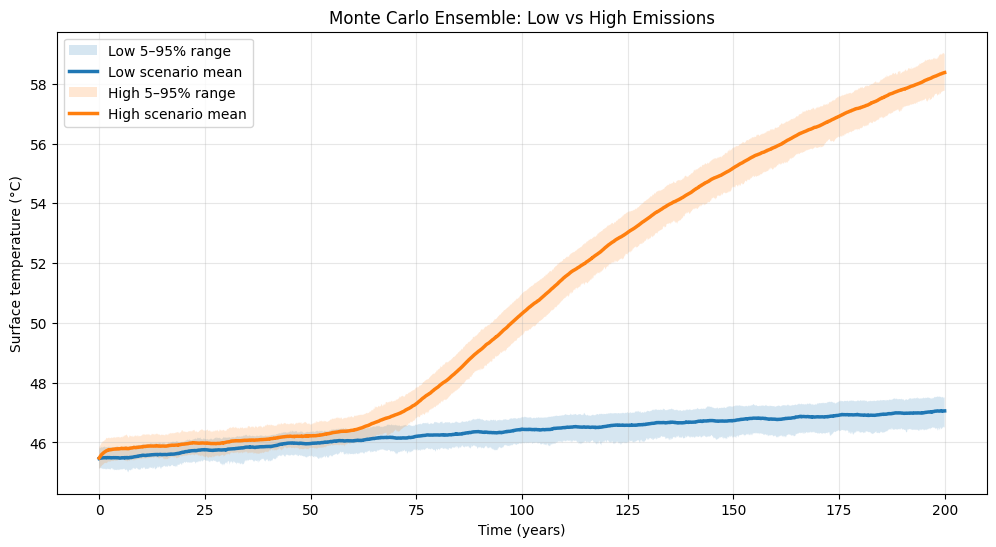

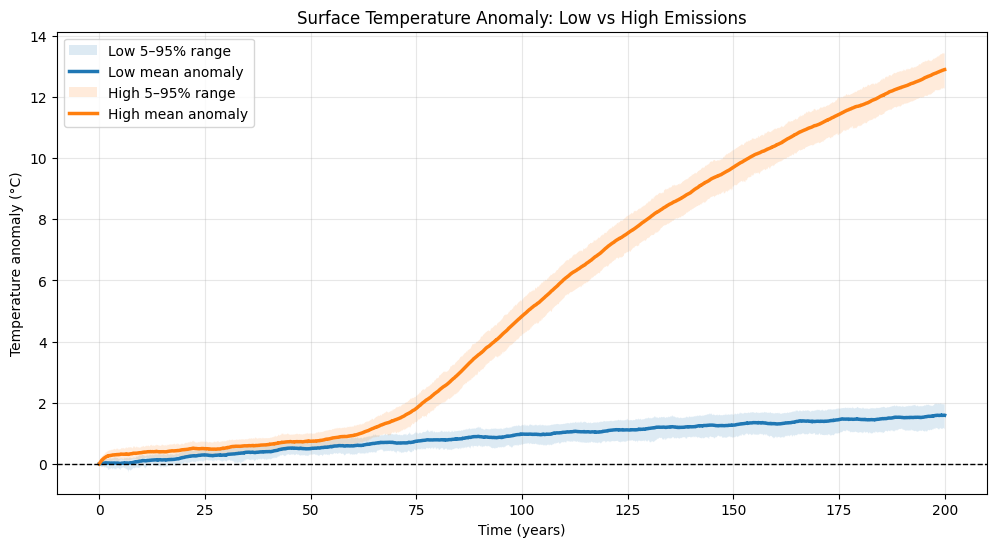

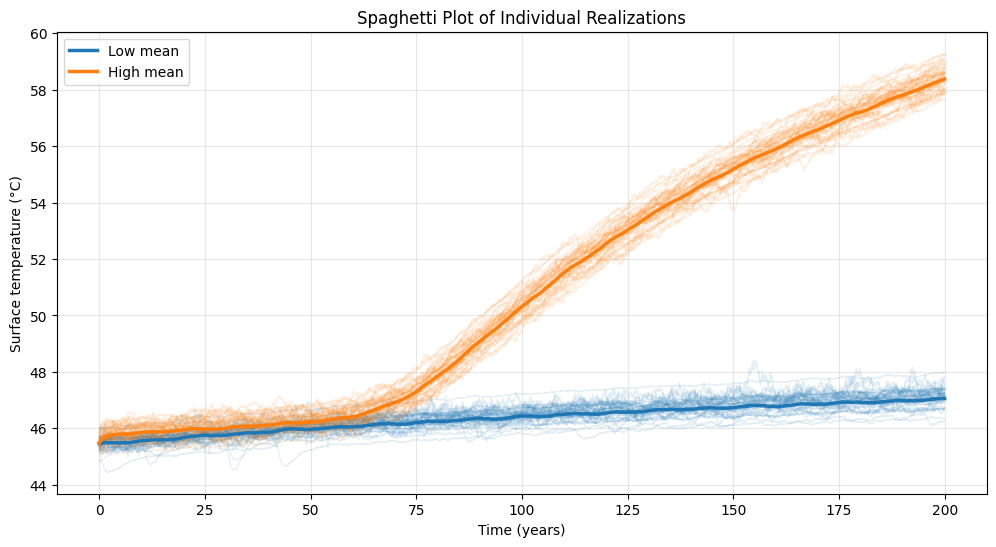

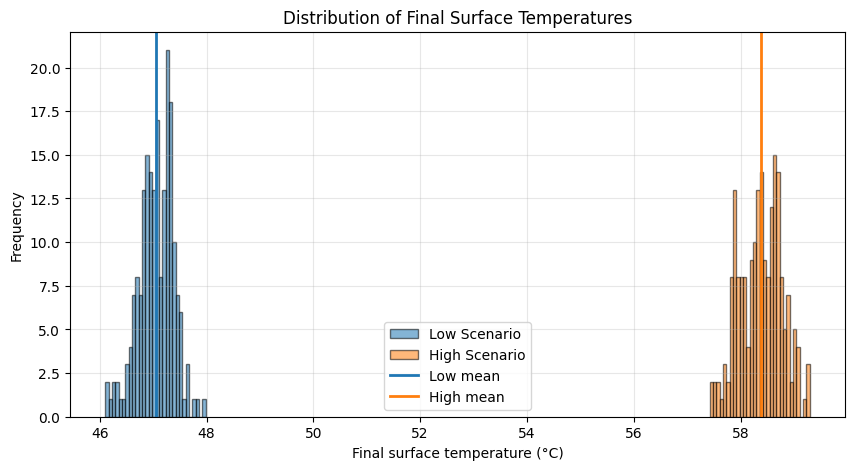

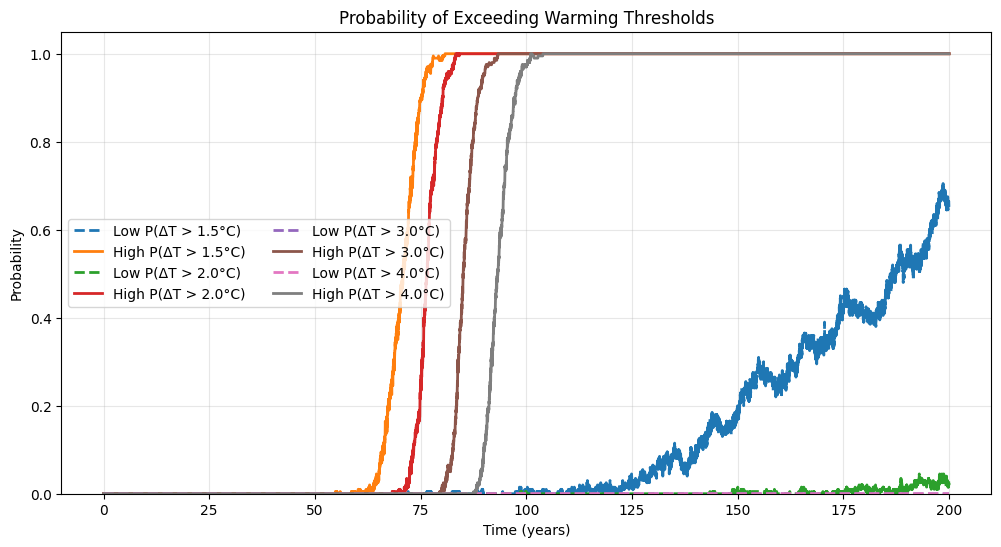

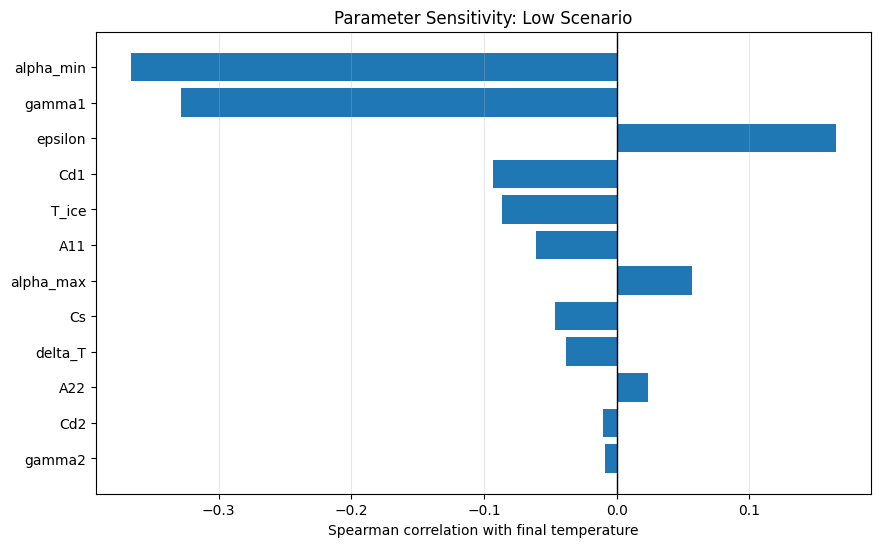

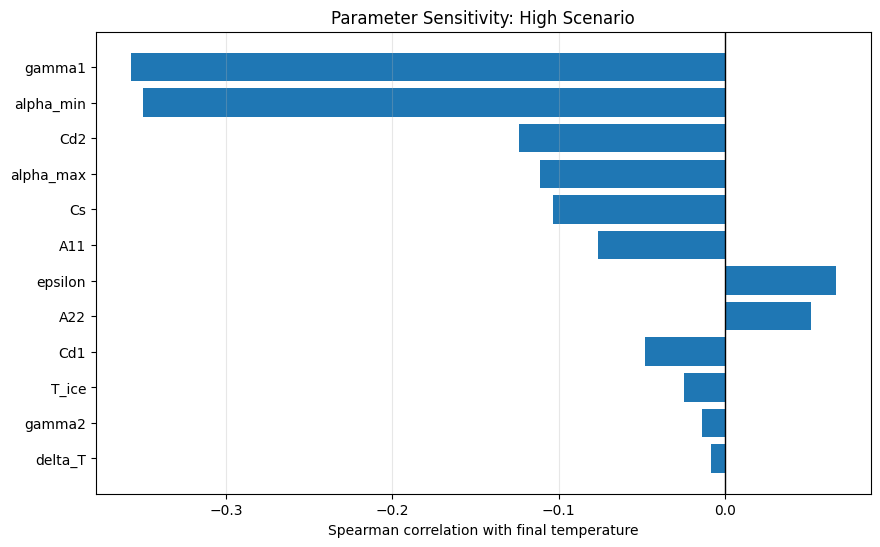

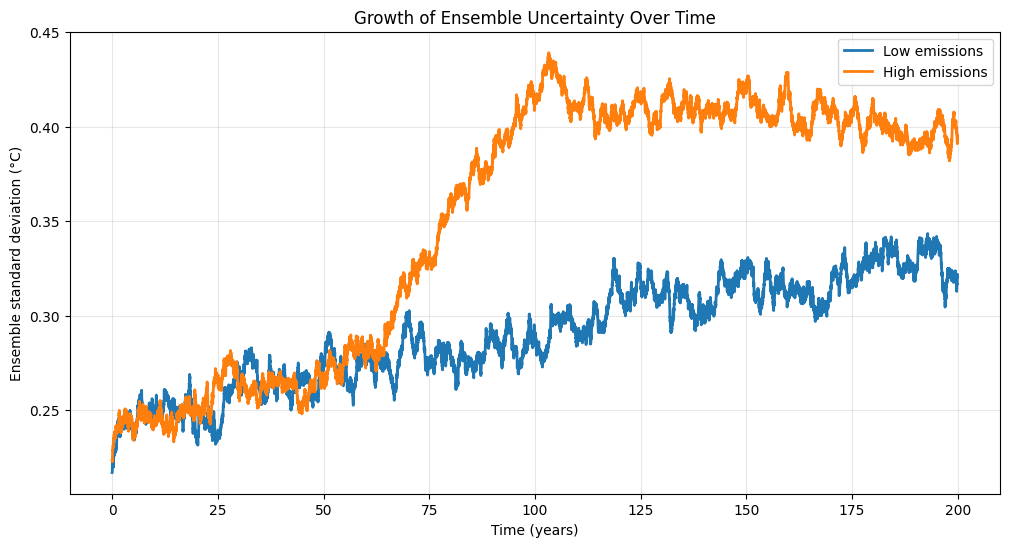

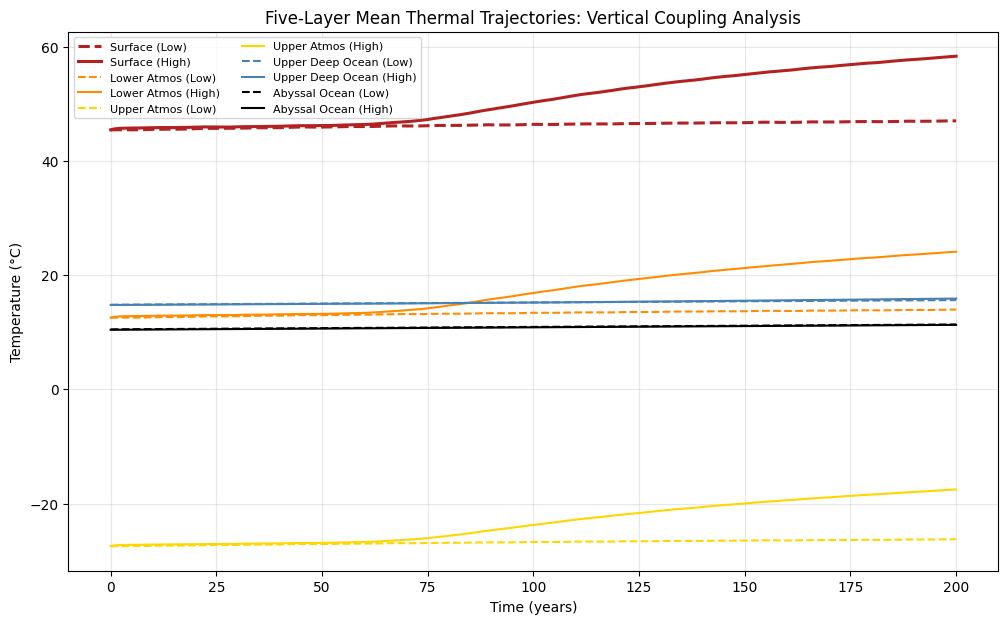

In [134]:
from scipy.stats import spearmanr

# -- Setup & Statistical Processing

# Extract final surface temperatures for probability distribution analysis
Ts_final_L = Ts_ensemble_L_C[:, -1]
Ts_final_H = Ts_ensemble_H_C[:, -1]

# Calculate the running standard deviation (spread) to track uncertainty evolution
Ts_std_L = np.std(Ts_ensemble_L_C, axis=0)
Ts_std_H = np.std(Ts_ensemble_H_C, axis=0)

# Calculate temperature anomalies relative to the start of each simulation
# This isolates the forced warming signal from initial climatological differences
Ts_anom_L = Ts_ensemble_L_C - Ts_ensemble_L_C[:, [0]]
Ts_anom_H = Ts_ensemble_H_C - Ts_ensemble_H_C[:, [0]]

Ts_anom_mean_L = np.mean(Ts_anom_L, axis=0)
Ts_anom_mean_H = np.mean(Ts_anom_H, axis=0)

# Calculate percentiles for anomaly-based uncertainty envelopes
Ts_anom_p05_L = np.percentile(Ts_anom_L, 5, axis=0)
Ts_anom_p95_L = np.percentile(Ts_anom_L, 95, axis=0)
Ts_anom_p05_H = np.percentile(Ts_anom_H, 5, axis=0)
Ts_anom_p95_H = np.percentile(Ts_anom_H, 95, axis=0)

# -- 1. Ensemble Mean + Uncertainty Envelope
# WHY: This is the 'Executive Summary' plot. It shows the expected trajectories
# for both scenarios alongside the 5-95% confidence intervals. It highlights
# the widening gap between the two emissions futures over time.
plt.figure(figsize=(12, 6))
plt.fill_between(time, Ts_p05_L, Ts_p95_L, alpha=0.18, label='Low 5–95% range')
plt.plot(time, Ts_mean_L, lw=2.5, label='Low scenario mean')
plt.fill_between(time, Ts_p05_H, Ts_p95_H, alpha=0.18, label='High 5–95% range')
plt.plot(time, Ts_mean_H, lw=2.5, label='High scenario mean')
plt.xlabel('Time (years)')
plt.ylabel('Surface temperature (°C)')
plt.title('Monte Carlo Ensemble: Low vs High Emissions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -- 2. Surface Temperature Anomaly
# WHY: Anomalies show the warming signal relative to the start of the simulation,
# effectively removing differences in initial state between ensemble members.
# This clearly visualizes the 'delta' in warming caused by different CO2 forcings.
plt.figure(figsize=(12, 6))
plt.fill_between(time, Ts_anom_p05_L, Ts_anom_p95_L, alpha=0.15, label='Low 5–95% range')
plt.plot(time, Ts_anom_mean_L, lw=2.5, label='Low mean anomaly')
plt.fill_between(time, Ts_anom_p05_H, Ts_anom_p95_H, alpha=0.15, label='High 5–95% range')
plt.plot(time, Ts_anom_mean_H, lw=2.5, label='High mean anomaly')
plt.axhline(0, color='black', ls='--', lw=1)
plt.xlabel('Time (years)')
plt.ylabel('Temperature anomaly (°C)')
plt.title('Surface Temperature Anomaly: Low vs High Emissions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -- 3. Spaghetti Plot
# WHY: While the mean shows the trend, spaghetti plots show individual
# 'realizations'. This illustrates the impact of stochastic weather noise
# and confirms that the ensemble mean isn't masking chaotic instabilities.
plt.figure(figsize=(12, 6))
n_spaghetti = min(40, n_runs)
idx_L = np.random.choice(n_runs, n_spaghetti, replace=False)
idx_H = np.random.choice(n_runs, n_spaghetti, replace=False)
for i in idx_L:
    plt.plot(time, Ts_ensemble_L_C[i], alpha=0.12, lw=0.8, color='C0')
for i in idx_H:
    plt.plot(time, Ts_ensemble_H_C[i], alpha=0.12, lw=0.8, color='C1')
plt.plot(time, Ts_mean_L, lw=2.5, color='C0', label='Low mean')
plt.plot(time, Ts_mean_H, lw=2.5, color='C1', label='High mean')
plt.xlabel('Time (years)')
plt.ylabel('Surface temperature (°C)')
plt.title('Spaghetti Plot of Individual Realizations')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -- 4. Final Temperature Distribution
# WHY: This histogram allows us to see the 'shape' of our final uncertainty.
# Comparing the overlap between the two scenarios reveals the statistical
# probability that the 'high' scenario will result in warmer states than 'low'.
plt.figure(figsize=(10, 5))
plt.hist(Ts_final_L, bins=30, alpha=0.55, edgecolor='black', label='Low Scenario')
plt.hist(Ts_final_H, bins=30, alpha=0.55, edgecolor='black', label='High Scenario')
plt.axvline(np.mean(Ts_final_L), color='C0', lw=2, label='Low mean')
plt.axvline(np.mean(Ts_final_H), color='C1', lw=2, label='High mean')
plt.xlabel('Final surface temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Surface Temperatures')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -- 5. Probability of Exceedance
# WHY: In climate policy, we care about specific limits (e.g. 1.5°C). This plot
# translates raw data into risk probabilities, showing how much earlier or more
# likely the ensemble is to cross critical thresholds in the high-emissions future.
thresholds = [1.5, 2.0, 3.0, 4.0]
plt.figure(figsize=(12, 6))
for threshold in thresholds:
    exceed_L = np.mean(Ts_anom_L > threshold, axis=0)
    exceed_H = np.mean(Ts_anom_H > threshold, axis=0)
    plt.plot(time, exceed_L, lw=2, ls='--', label=f'Low P(ΔT > {threshold}°C)')
    plt.plot(time, exceed_H, lw=2, label=f'High P(ΔT > {threshold}°C)')
plt.xlabel('Time (years)')
plt.ylabel('Probability')
plt.title('Probability of Exceeding Warming Thresholds')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

# -- 6. Parameter Sensitivity Ranking
# WHY: This reveals which sampled parameters drive the most final uncertainty.
# By correlating inputs (e.g. epsilon, Cs) with final temps, we identify which
# variables are the most critical drivers of climate sensitivity in our model.
param_names = ["epsilon", "gamma1", "gamma2", "alpha_min", "alpha_max", "T_ice", "delta_T", "Cs", "Cd1", "Cd2", "A11", "A22"]
def plot_sensitivity(params_used, Ts_final, title):
    sensitivity_names, sensitivity_values = [], []
    for name in param_names:
        try:
            values = np.array([p[name] for p in params_used])
            r, _ = spearmanr(values, Ts_final)
            if np.isfinite(r):
                sensitivity_names.append(name); sensitivity_values.append(r)
        except: pass
    sensitivity_values = np.array(sensitivity_values)
    order = np.argsort(np.abs(sensitivity_values))
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(sensitivity_names)[order], sensitivity_values[order])
    plt.axvline(0, color='black', lw=1)
    plt.xlabel('Spearman correlation with final temperature')
    plt.title(title); plt.grid(True, axis='x', alpha=0.3); plt.show()

plot_sensitivity(params_used_L, Ts_final_L, 'Parameter Sensitivity: Low Scenario')
plot_sensitivity(params_used_H, Ts_final_H, 'Parameter Sensitivity: High Scenario')

# -- 7. Ensemble Uncertainty Growth
# WHY: Tracking standard deviation over time shows whether the model spread
# stabilizes or explodes. Rapid growth in the 'high' scenario often indicates
# that stronger feedbacks are magnifying initial parameter uncertainties.
plt.figure(figsize=(12, 6))
plt.plot(time, Ts_std_L, lw=2, label='Low emissions')
plt.plot(time, Ts_std_H, lw=2, label='High emissions')
plt.xlabel('Time (years)')
plt.ylabel('Ensemble standard deviation (°C)')
plt.title('Growth of Ensemble Uncertainty Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -- 8. Five-Layer Mean Trajectories
# WHY: This visualizes the vertical thermal coupling of the entire system.
# It demonstrates how quickly heat penetrates from the surface through the
# atmosphere and eventually into the slow-responding deep ocean layers.
plt.figure(figsize=(12, 7))
# Surface
plt.plot(time, Ts_mean_L,  lw=2.2, ls='--', color='firebrick', label='Surface (Low)')
plt.plot(time, Ts_mean_H,  lw=2.2, ls='-',  color='firebrick', label='Surface (High)')
# Lower Atmosphere
plt.plot(time, Ta2_mean_L, lw=1.5, ls='--', color='darkorange', label='Lower Atmos (Low)')
plt.plot(time, Ta2_mean_H, lw=1.5, ls='-',  color='darkorange', label='Lower Atmos (High)')
# Upper Atmosphere
plt.plot(time, Ta1_mean_L, lw=1.5, ls='--', color='gold', label='Upper Atmos (Low)')
plt.plot(time, Ta1_mean_H, lw=1.5, ls='-',  color='gold', label='Upper Atmos (High)')
# Upper Deep Ocean
plt.plot(time, Td1_mean_L, lw=1.5, ls='--', color='steelblue', label='Upper Deep Ocean (Low)')
plt.plot(time, Td1_mean_H, lw=1.5, ls='-',  color='steelblue', label='Upper Deep Ocean (High)')
# Lower Deep Ocean (Abyssal)
plt.plot(time, Td2_mean_L, lw=1.5, ls='--', color='black', label='Abyssal Ocean (Low)')
plt.plot(time, Td2_mean_H, lw=1.5, ls='-',  color='black', label='Abyssal Ocean (High)')

plt.xlabel('Time (years)')
plt.ylabel('Temperature (°C)')
plt.title('Five-Layer Mean Thermal Trajectories: Vertical Coupling Analysis')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8, loc='best')
plt.show()

#Discussion

## Interpretation of Results

###
The results show a clear divergence between the low-emissions and high-emissions pathways. In the main ensemble projection, the low-emissions scenario warms only gradually, while the high-emissions scenario rises rapidly after around 70–80 years and reaches a much warmer final state. This separation is also visible in the final-temperature histogram, where the low- and high-emissions outcomes form two distinct clusters rather than overlapping distributions.

The exceedance-probability plot shows that high emissions quickly reaches a near-certain probability of exceeding 1.5°C, 2°C, 3°C and 4°C warming thresholds, while the low-emissions case remains much less likely to cross the higher thresholds. The sensitivity plots suggest that uncertainty in final temperature is mainly controlled by parameters linked to greenhouse strength, albedo and ocean heat exchange. The five-layer trajectory plot also shows that the surface and atmosphere respond much faster than the deep ocean, highlighting the role of ocean thermal inertia.

Overall, the model suggests that the emissions pathway is the dominant control on future warming, while parameter uncertainty affects the spread around each scenario.

## Limitations and Uncertainty

###

This model has several important limitations and sources of uncertainty. First, it uses global mean values, so it does not include spatial variation across latitude, land and ocean, the poles, the tropics, or regional climate systems. This means it cannot represent processes such as polar amplification, regional cloud cover, ocean circulation patterns, ENSO, monsoons, or Australian-scale extremes. Second, many parameters are derived from modern observations that are not in perfect equilibrium. For example, present-day radiation fluxes, surface temperature and ocean heat uptake are affected by ongoing anthropogenic forcing, so deriving equilibrium parameters from these observations assumes that the system is closer to balance than it really is. This may bias estimated values such as emissivity, albedo behaviour and ocean heat exchange. Third, the model ignores many finer-scale energy fluxes, including latent heat transfer, sensible heat transfer, evaporation, convection, cloud feedbacks, water vapour feedback and atmospheric circulation. These processes are partly hidden inside the fitted parameters, but they are not explicitly represented, which limits the physical realism of the model.

A major uncertainty is the treatment of atmospheric emissivity. The model assumes both atmospheric layers have the same emissivity, even though the real atmosphere has vertical variation in temperature, pressure, water vapour, clouds and greenhouse gas absorption. In addition, the emissivity derivation uses a simplified single-atmosphere-layer relationship to estimate a value that is then applied in a two-layer atmosphere model. This creates a structural inconsistency: an emissivity that gives reasonable outgoing longwave radiation in a one-layer model may produce too much greenhouse trapping when applied to two emitting atmospheric layers. This is likely one reason the model spins up to an equilibrium above 40°C. Other possible causes include underestimated planetary albedo, too-strong back-radiation from the atmosphere, missing cooling terms such as latent and sensible heat fluxes, weak ocean heat uptake, or deriving parameters from observations during a non-equilibrium warming period. Therefore, the high spin-up equilibrium suggests that the model is internally consistent with its own assumptions, but that some of those assumptions are physically too simplified or incorrectly calibrated. Overall, the model is best interpreted as a transparent experiment for exploring climate feedbacks, uncertainty and scenario differences, rather than as a fully realistic Earth system prediction.

# References

## Data Sources and References

The model was built using observational climate datasets from the following sources. Some datasets were accessed through CSV/text files stored in the project GitHub repository, but the original data providers are listed below.

### Surface Temperature

- NASA GISS Surface Temperature Analysis, GISTEMP
- Used for global mean surface temperature anomalies and conversion to approximate absolute surface temperature.
- Source: https://data.giss.nasa.gov/gistemp/

### Atmospheric CO₂

- NOAA Global Monitoring Laboratory, Mauna Loa monthly atmospheric CO₂ record
- Used to derive the long-term CO₂ trend and annual seasonal cycle.
- Source: https://gml.noaa.gov/ccgg/trends/data.html

### Radiation Fluxes and Albedo

- ERA5 reanalysis, Copernicus Climate Change Service / ECMWF
- Used for top-of-atmosphere and surface radiation fluxes, including shortwave and longwave radiation.
- Variables used included downward shortwave radiation, net shortwave radiation, net longwave radiation and forecast albedo.
- Source: https://cds.climate.copernicus.eu/

### Solar Irradiance

- Total Solar Irradiance composite observations, including SORCE/TIM-style TSI records
- Used to calculate mean solar irradiance and extract 11-year and 22-year solar cycle amplitudes using FFT analysis.
- Source: https://lasp.colorado.edu/

### Ocean Temperature

- Scripps / Argo ocean temperature anomaly records
- Used for 0–2000 m and 2000–6000 m ocean temperature time series.
- These records were used to derive ocean heat exchange coefficients and initialise deep-ocean layers.
- Source: https://argo.ucsd.edu/

### CO₂ Radiative Forcing Relationship

- The model uses the standard logarithmic CO₂ forcing relationship:

$$
F_{CO_2} = 5.35 \ln \left( \frac{C}{C_0} \right)
$$

- This relationship is commonly attributed to Myhre et al. and is widely used in simple climate models and IPCC-style radiative forcing calculations.

### Project Data Access

- Several processed datasets were accessed from the project GitHub repository as CSV or text files.
- These files were used for reproducibility and convenient loading into Google Colab.
- Original data ownership remains with the providers listed above.

# Archived Code

In [ ]:
# --- Used to spatially avg ERA files and save outputs

# Path to the .nc file
#file_path = '.nc'

# Read the NetCDF file
#dataset = xr.open_dataset(file_path)

#print(dataset)

#spatial_mean_over_time = dataset.mean(dim=['latitude', 'longitude'], skipna=True)

#print(spatial_mean_over_time)

#output_filename = '.nc'
#spatial_mean_over_time.to_netcdf(output_filename)
# Convert to DataFrame (ideal for time-series data)
#df = ds.to_dataframe().reset_index()

# Save to CSV
#csv_filename = nc_file.replace('.nc', '.csv')
#df.to_csv(csv_filename, index=False)

In [ ]:
# --- Used to determine the best fitting model

#data["x2"] = data["x"] ** 2 #used for quadratic regression
#data["x3"] = data["x"] ** 3 #used for cubic regression
#data["x4"] = data["x"] ** 4 #used for quartic regression

# Fit a straight-line model (first-order polynomial)
#model_linear = bmb.Model("y ~ x", data)
#idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True})

# Fit a quadratic model (second-order polynomial)
#model_quad = bmb.Model("y ~ x + x2", data)
#idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True})

# Fit a cubic model (third-order polynomial)
#model_cubic = bmb.Model("y ~ x + x2 + x3", data)
#idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True})

# Fit a quartic model (fourth-order polynomial)
#model_quart = bmb.Model("y ~ x + x2 + x3 + x4", data)
#idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True})

# Compare models
#comparison = az.compare({
#    "linear": idata_linear,
#    "quadratic": idata_quad,
#    "cubic": idata_cubic,
#    "quartic": idata_quart
#})
#print(comparison) #print the result